# 05 — SARIMAX: Pronóstico con Variables Exógenas
**Sistema de Pronóstico de Rentas Cedidas** | ADRES — Colombia

---

| Fase | Contenido | Método |
|------|-----------|--------|
| I | Carga, split Oct 2021 – Dic 2025, log1p | Validación OOS Oct–Dic 2025 |
| II | 5 exógenas: IPC, UPC, SMLV, Consumo, Desempleo | Índices acumulados (log) |
| III | Granger + β + ΔAICc individual | Regla de pre-filtro |
| IV | Grid search 2 etapas (32 configs × top-3) | AICc + parsimonia |
| V | Modelo óptimo + diagnóstico residuos | Ljung-Box, Shapiro, Levene |
| VI | OOS (3 m) + producción 2026 (12 m) | IC 95 % |
| VII | SARIMAX vs SARIMA + recomendación | Elección final |

### Variables Exógenas

| Variable | Fuente | Hipótesis | 2026 |
|----------|--------|-----------|------|
| **IPC** | DANE | Nominal vs orgánico | 5.10 % |
| **UPC** | MinSalud | Gasto → recaudo SGSSS | +7.00 % |
| **SMLV** | Decreto | Poder adquisitivo | $1,750,905 |
| **Consumo** | BM/DANE | Demanda agregada | +2.50 % |
| **Desempleo** | DANE GEIH | Capacidad contributiva hogares | 9.30 % |

> **NB 03:** VIF = ∞ entre IPC, SMLV y UPC.  Se evalúan las **31 combinaciones**
> no vacías de 5 variables para encontrar la que aporta información **marginal** al SARIMA.

### Hipótesis: Desempleo
Mayor desempleo → menor capacidad de consumo formal → menor base imponible
sobre licores, cigarrillos y juegos de azar → **menor recaudo de rentas cedidas**.
Se espera un coeficiente **negativo** en log-log (elasticidad inversa).

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasCedidasVF.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica


Serie: 51m | Entrenamiento: 48m (2021-10-01→2025-09-01) | Prueba: 3m (2025-10-01→2025-12-01)
Media: $255.7MM | CV orig: 0.2797 → log: 0.009799


  📊 Figura guardada: 05_sarimax_split.png


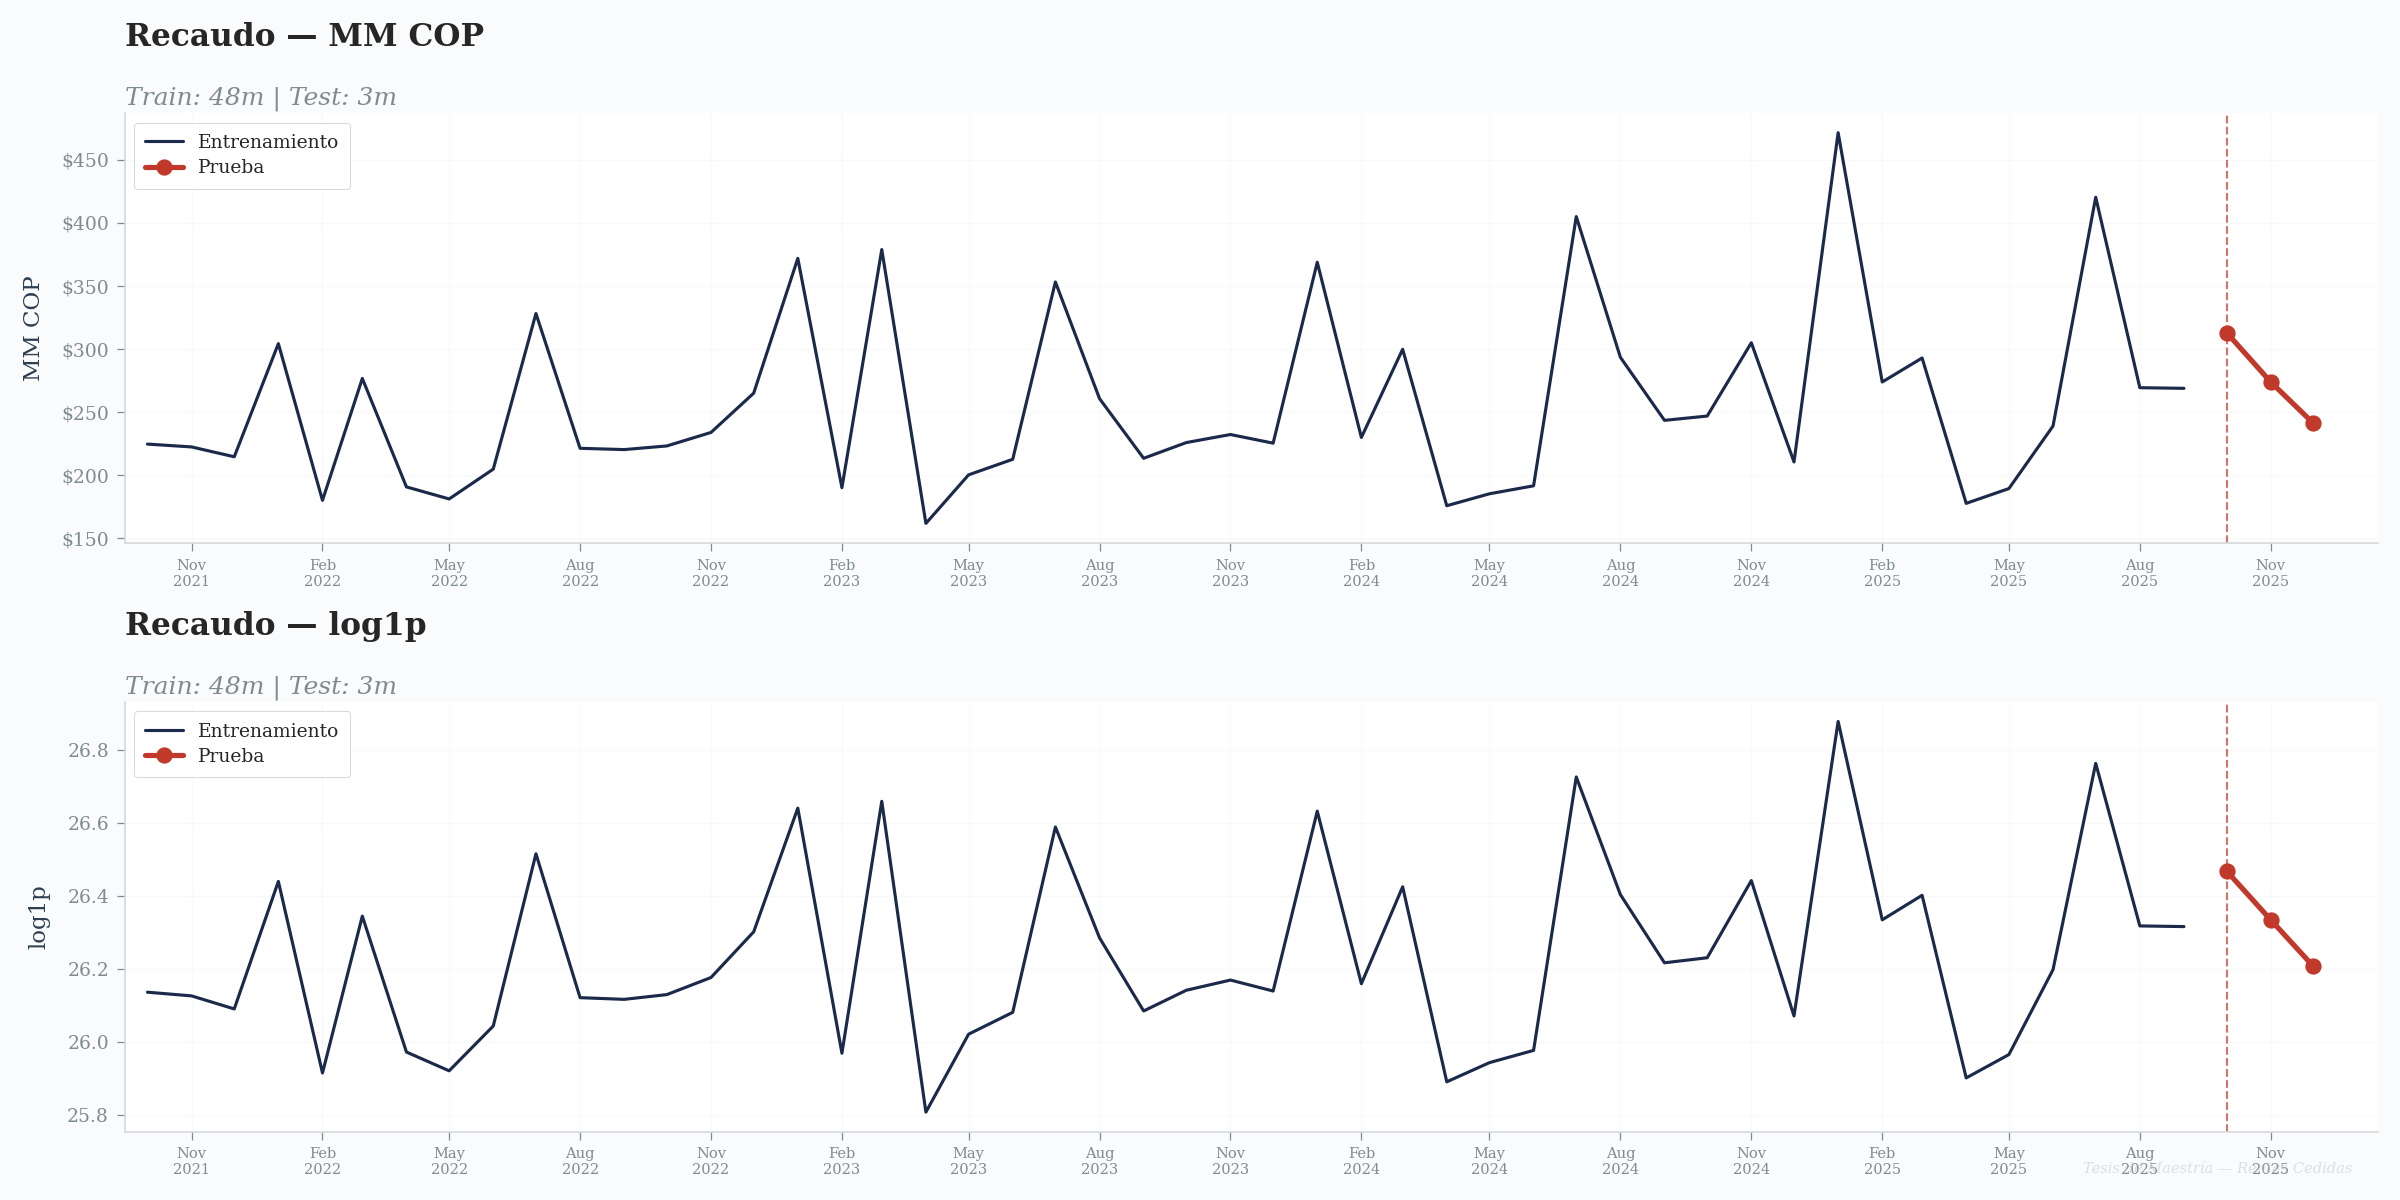

In [1]:
# ══════════════════════════════════════════════════════════════
# FASE I — Setup, Carga, Split y Estabilización de Varianza
# ══════════════════════════════════════════════════════════════
%run 00_config.py

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from itertools import product, combinations
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import (mean_absolute_percentage_error,
                             mean_squared_error, mean_absolute_error)
import time, warnings
warnings.filterwarnings('ignore')

SMLV_COP = {2021: 908_526, 2022: 1_000_000, 2023: 1_160_000,
             2024: 1_300_000, 2025: 1_423_500, 2026: 1_750_905}

# ── Carga ──
df_serie = pd.read_csv(DATA_PROCESSED / 'serie_mensual.csv',
                       parse_dates=['Fecha'], index_col='Fecha')
df_serie.index.freq = 'MS'
serie_full = df_serie['Recaudo_Total'].copy()

# ── Split: Train hasta Sep 2025, Test Oct-Dic 2025 ──
VAL_START = VALIDATION_START
train = serie_full.loc[:pd.Timestamp(VAL_START) - pd.DateOffset(months=1)]
test  = serie_full.loc[VAL_START:VALIDATION_END]
train_log, test_log = np.log1p(train), np.log1p(test)

cv_o, cv_l = train.std()/train.mean(), train_log.std()/train_log.mean()
print(f"Serie: {len(serie_full)}m | Entrenamiento: {len(train)}m "
      f"({train.index[0].date()}→{train.index[-1].date()}) | "
      f"Prueba: {len(test)}m ({test.index[0].date()}→{test.index[-1].date()})")
print(f"Media: ${train.mean()/1e9:,.1f}MM | CV orig: {cv_o:.4f} → log: {cv_l:.6f}")

# ── Viz ──
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
for ax, (s_tr, s_te, ylabel) in zip(axes, [
    (train/1e9, test/1e9, 'MM COP'),
    (train_log, test_log, 'log1p')]):
    ax.plot(s_tr.index, s_tr.values, color=C_PRIMARY, lw=1.5, label='Entrenamiento')
    ax.plot(s_te.index, s_te.values, color=C_SECONDARY, lw=2.5,
            marker='o', ms=7, label='Prueba')
    ax.axvline(pd.Timestamp(VAL_START), color=C_SECONDARY, ls='--', lw=1, alpha=.7)
    ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2026-01-15'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.tick_params(axis='x', labelsize=7); ax.grid(True, alpha=.3)
    ax.set_ylabel(ylabel)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, f'Recaudo — {ylabel}',
                           f'Train: {len(s_tr)}m | Test: {len(s_te)}m')
        if ylabel == 'MM COP': formato_pesos_eje(ax, eje='y')
        leyenda_profesional(ax, loc='upper left')
plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig); guardar_figura(fig, '05_sarimax_split', OUTPUTS_FIGURES)
plt.show()

---
## Fase II — Construcción de 5 Variables Exógenas

Se construyen **índices acumulados** (base 2020 = 100) para UPC y Consumo.
IPC proviene de `serie_mensual.csv`. SMLV es step-function en COP.
**Desempleo** es la tasa anual (%) del DANE GEIH, asignada mensualmente.
Todas se transforman a **log** para interpretación como elasticidades.

══════════════════════════════════════════════════════════════════════
VARIABLES EXÓGENAS (5 candidatas, log)
══════════════════════════════════════════════════════════════════════
  IPC         : [4.605, 4.918] | r_Recaudo = +0.248 ↑ (p=0.0891)
  UPC         : [4.654, 5.048] | r_Recaudo = +0.252 ↑ (p=0.0835)
  SMLV        : [13.720, 14.169] | r_Recaudo = +0.255 ↑ (p=0.0808)
  Consumo     : [4.742, 4.890] | r_Recaudo = +0.214 ↑ (p=0.1441)
  Desempleo   : [2.251, 2.617] | r_Recaudo = -0.228 ↓ (p=0.1195)


  📊 Figura guardada: 05_exogenas_exploracion.png


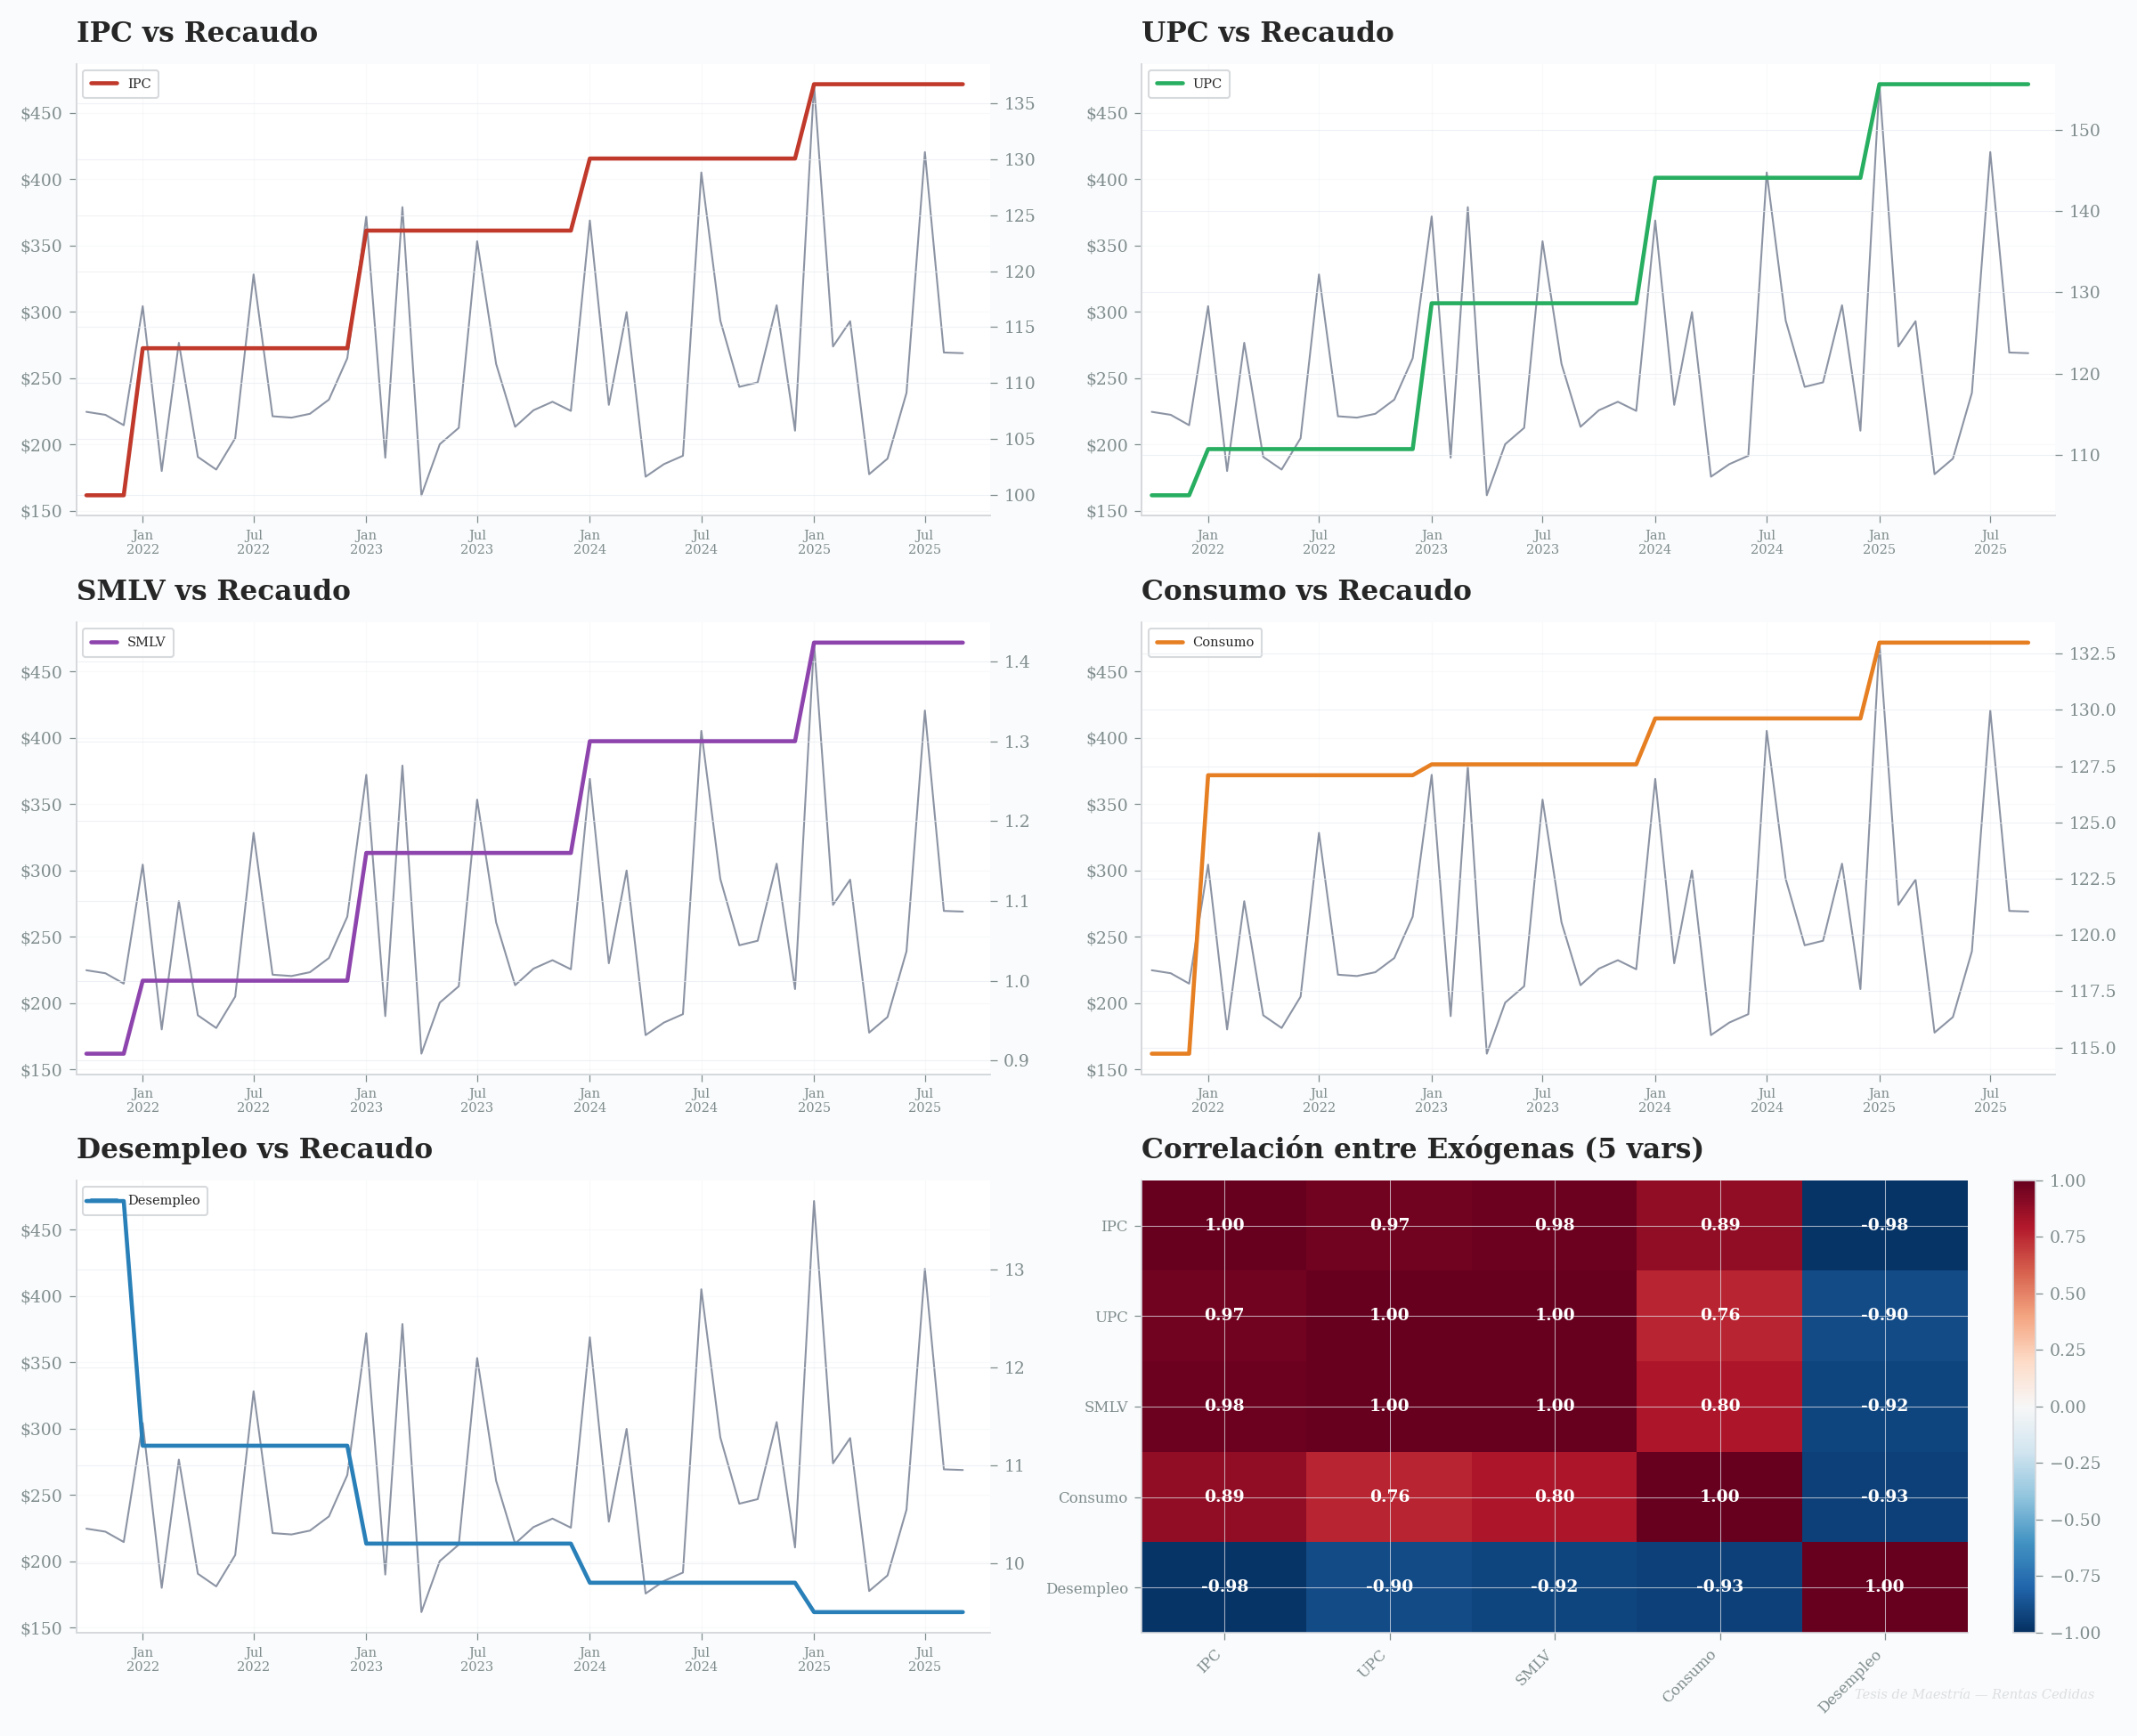

  📊 Figura guardada: 05_desempleo_vs_recaudo.png


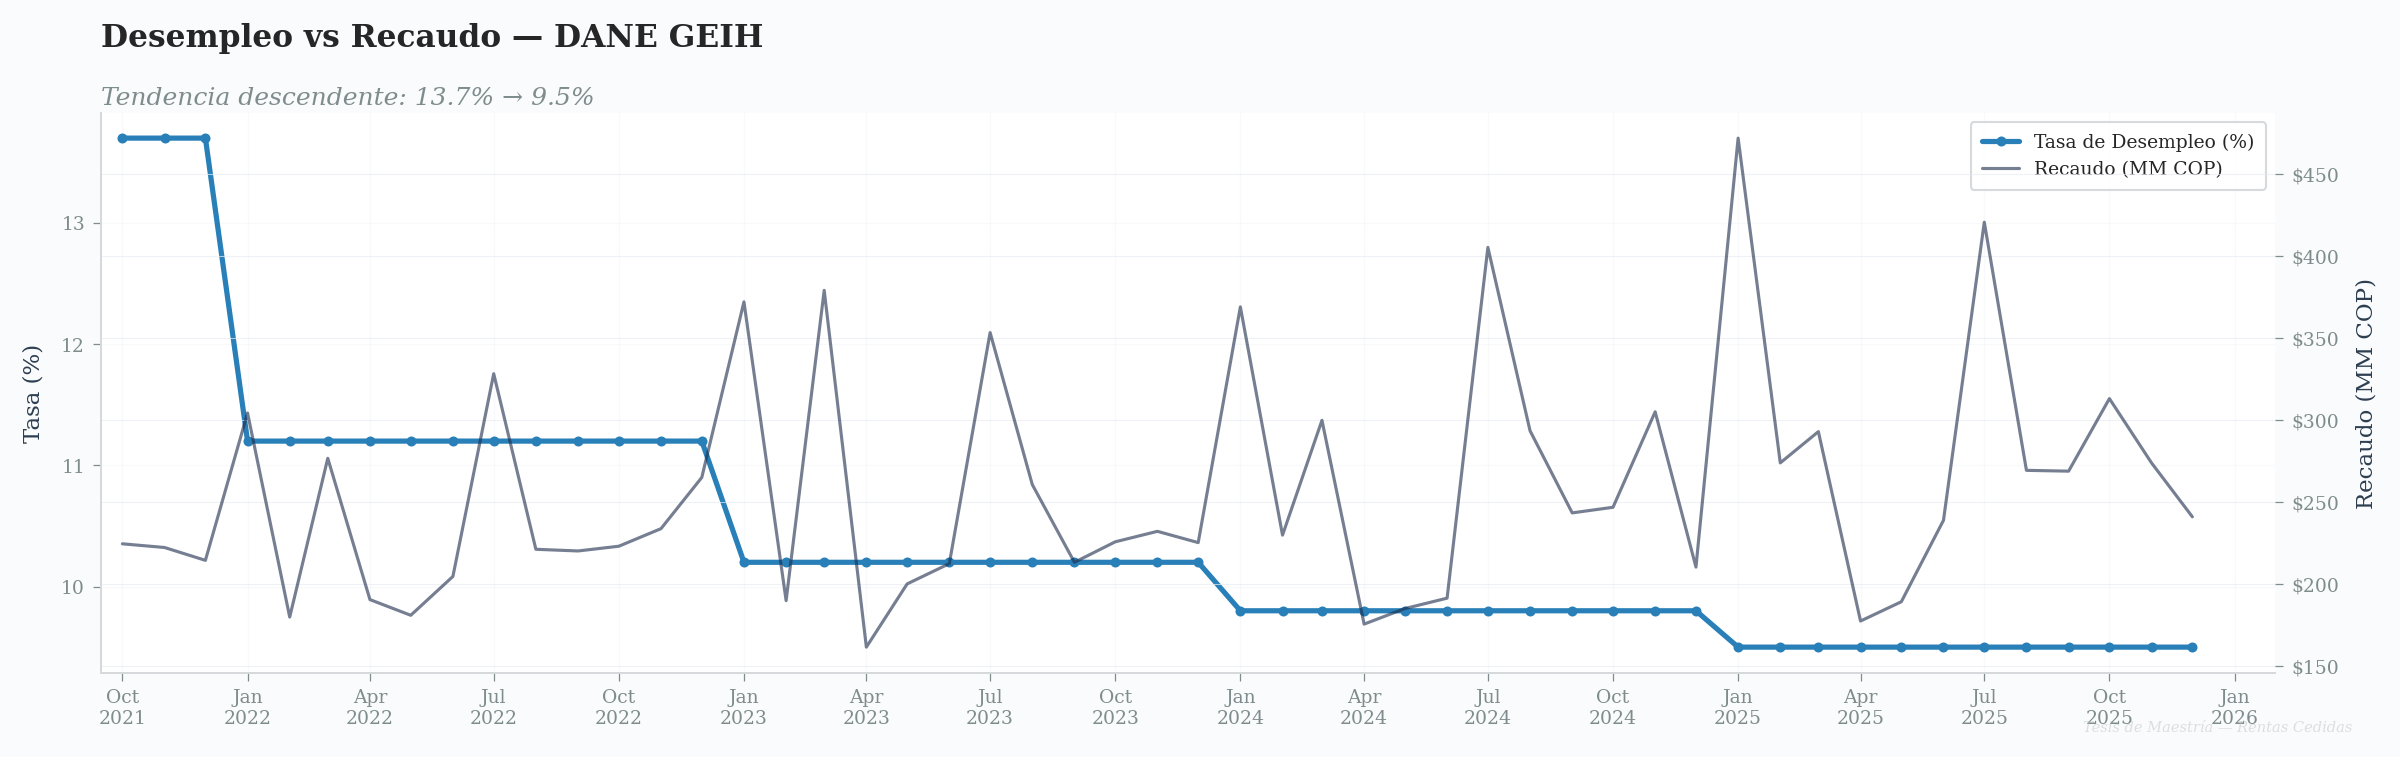

In [2]:
# ══════════════════════════════════════════════════════════════
# FASE II — Construcción de Exógenas + Correlación + Viz
# ══════════════════════════════════════════════════════════════

# ── Helper: índice acumulado desde MACRO_DATA ──
def build_cum_index(key):
    base = 100.0
    idx = {}
    for y in sorted(MACRO_DATA.keys()):
        base *= (1 + MACRO_DATA[y].get(key, 0) / 100)
        idx[y] = base
    return idx

# ── Construir las 5 series mensuales ──
ipc_full = df_serie['IPC_Indice'].copy()
upc_idx  = build_cum_index('UPC')
cons_idx = build_cum_index('Consumo_Hogares')

ALL_EXOG = ['IPC', 'UPC', 'SMLV', 'Consumo', 'Desempleo']

raw_series = {
    'IPC':       ipc_full,
    'UPC':       serie_full.index.to_series().apply(lambda d: upc_idx.get(d.year, np.nan)),
    'SMLV':      serie_full.index.to_series().apply(lambda d: SMLV_COP.get(d.year, np.nan)),
    'Consumo':   serie_full.index.to_series().apply(lambda d: cons_idx.get(d.year, np.nan)),
    'Desempleo': serie_full.index.to_series().apply(
                     lambda d: MACRO_DATA.get(d.year, {}).get('Desempleo', np.nan)),
}
for k in raw_series:
    raw_series[k].index = serie_full.index

# ── DataFrame log ──
exog_full = pd.DataFrame({k: np.log(v) for k, v in raw_series.items()},
                          index=serie_full.index)
exog_train = exog_full.loc[train.index]
exog_test  = exog_full.loc[test.index]

# ── Resumen ──
print(f"{'═'*70}\nVARIABLES EXÓGENAS (5 candidatas, log)\n{'═'*70}")
for col in ALL_EXOG:
    v = exog_full[col].dropna()
    r_p, p_p = stats.pearsonr(exog_train[col].dropna(),
                               train_log.loc[exog_train[col].dropna().index])
    signo = '↑' if r_p > 0 else '↓'
    print(f"  {col:<12}: [{v.min():.3f}, {v.max():.3f}] | "
          f"r_Recaudo = {r_p:+.3f} {signo} (p={p_p:.4f})")

# ── Viz: 5 paneles + correlación ──
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
colors = [C_SECONDARY, C_QUATERNARY, C_SENARY, C_QUINARY, C_TERTIARY]

for i, (name, color) in enumerate(zip(ALL_EXOG, colors)):
    row, col_p = divmod(i, 2)
    ax = axes[row, col_p]
    ax.plot(train.index, train.values/1e9, color=C_PRIMARY, lw=1, alpha=.5)
    ax_r = ax.twinx()
    rs = raw_series[name].loc[train.index]
    if name == 'SMLV': rs = rs / 1e6
    ax_r.plot(rs.index, rs.values, color=color, lw=2.2, label=name)
    ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2025-10-15'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.tick_params(axis='x', labelsize=7); ax.grid(True, alpha=.3)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, f'{name} vs Recaudo', '')
        formato_pesos_eje(ax, eje='y')
    h1,l1 = ax.get_legend_handles_labels()
    h2,l2 = ax_r.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, fontsize=7, loc='upper left')

# Correlación 5×5
ax = axes[2, 1]
corr = exog_train.corr()
n_vars = len(ALL_EXOG)
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(n_vars)); ax.set_yticks(range(n_vars))
ax.set_xticklabels(ALL_EXOG, fontsize=8, rotation=45, ha='right')
ax.set_yticklabels(ALL_EXOG, fontsize=8)
for ii in range(n_vars):
    for jj in range(n_vars):
        ax.text(jj, ii, f'{corr.values[ii,jj]:.2f}', ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if abs(corr.values[ii,jj]) > .6 else 'black')
plt.colorbar(im, ax=ax, fraction=.046)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Correlación entre Exógenas (5 vars)', '')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig); guardar_figura(fig, '05_exogenas_exploracion', OUTPUTS_FIGURES)
plt.show()

# ── Serie de Desempleo individual ──
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(raw_series['Desempleo'].index, raw_series['Desempleo'].values,
        color=C_TERTIARY, lw=2.5, marker='o', ms=4, label='Tasa de Desempleo (%)')
ax.set_ylabel('Tasa (%)')
ax.grid(True, alpha=.3)
ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2025-12-31') + pd.DateOffset(months=1))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax_r = ax.twinx()
ax_r.plot(serie_full.index, serie_full.values/1e9, color=C_PRIMARY, lw=1.5, alpha=.6,
          label='Recaudo (MM COP)')
ax_r.set_ylabel('Recaudo (MM COP)')
h1,l1 = ax.get_legend_handles_labels()
h2,l2 = ax_r.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, fontsize=9, loc='upper right')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Desempleo vs Recaudo — DANE GEIH',
                       f'Tendencia descendente: {raw_series["Desempleo"].iloc[0]:.1f}% → {raw_series["Desempleo"].iloc[-1]:.1f}%')
    formato_pesos_eje(ax_r, eje='y')
    marca_agua(fig); guardar_figura(fig, '05_desempleo_vs_recaudo', OUTPUTS_FIGURES)
plt.tight_layout()
plt.show()

---
## Fases III-IV — Causalidad Individual + Grid Search 2 Etapas

**Fase III** — Pre-filtro individual (Granger, β, ΔAICc) para las **5 variables** (IPC, UPC, SMLV, Consumo, Desempleo).
**Fase IV** — Grid search optimizado:
1. **Etapa 1:** 36 órdenes SARIMA sin exógenas → seleccionar top-5.
2. **Etapa 2:** 32 configs (sin + 31 combos de 5 vars) × top-3 órdenes = 96 modelos.
3. **Total:** ~132 modelos.

$$\text{AICc} = \text{AIC} + \frac{2k(k+1)}{n - k - 1}$$

In [3]:
# ══════════════════════════════════════════════════════════════
# FASES III-IV — Pre-filtro Individual + Grid Search 2 Etapas
# ══════════════════════════════════════════════════════════════

def calc_aicc(aic, k, n):
    d = n - k - 1
    return aic + 2*k*(k+1)/d if d > 0 else np.inf

# ────────────────────────────────────────────────
# FASE III — Granger + β + ΔAICc (individual)
# ────────────────────────────────────────────────
print(f"{'═'*70}\nFASE III — PRE-FILTRO INDIVIDUAL\n{'═'*70}")

# Granger sobre primeras diferencias
d1_y = train_log.diff().dropna()
d1_x = exog_train.diff().dropna()
ci = d1_y.index.intersection(d1_x.index)

granger = {}
for col in ALL_EXOG:
    try:
        gc = grangercausalitytests(
            np.column_stack([d1_y.loc[ci].values, d1_x.loc[ci, col].values]),
            maxlag=4, verbose=False)
        pvals = [gc[l+1][0]['ssr_ftest'][1] for l in range(4)]
        granger[col] = min(pvals) < 0.05
        print(f"  Granger {col:<10}: min_p = {min(pvals):.4f} "
              f"{'✅' if granger[col] else '❌'}")
    except Exception:
        granger[col] = False

# SARIMAX individual (0,1,0)(0,1,0,12) + variable
base = SARIMAX(train_log, order=(0,1,0), seasonal_order=(0,1,0,12),
               enforce_stationarity=False, enforce_invertibility=False
               ).fit(disp=False)
k_b, n_b = base.df_model+1, base.nobs
aicc_b = calc_aicc(base.aic, k_b, n_b)

indiv = {}
print(f"\n  Base AICc = {aicc_b:.2f}")
for col in ALL_EXOG:
    try:
        res = SARIMAX(train_log, exog=exog_train[[col]], order=(0,1,0),
                      seasonal_order=(0,1,0,12), enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)
        idx_c = list(res.param_names).index(col) if col in res.param_names else 0
        k_r = res.df_model+1
        aicc_r = calc_aicc(res.aic, k_r, res.nobs)
        sig = res.pvalues[idx_c] < 0.05
        mejora = (aicc_r - aicc_b) < -2
        score = sum([granger.get(col, False), sig, mejora])
        indiv[col] = {'sig': sig, 'mejora': mejora, 'score': score,
                      'delta': aicc_r - aicc_b, 'pval': res.pvalues[idx_c]}
        print(f"  + {col:<10}: β p={res.pvalues[idx_c]:.4f} "
              f"ΔAICc={aicc_r-aicc_b:+.2f} score={score}/3 "
              f"{'✅' if score >= 1 else '❌'}")
    except Exception:
        indiv[col] = {'sig': False, 'mejora': False, 'score': 0,
                      'delta': np.inf, 'pval': 1.0}

# ────────────────────────────────────────────────
# FASE IV — Grid Search 2 Etapas
# ────────────────────────────────────────────────
print(f"\n{'═'*70}\nFASE IV — GRID SEARCH 2 ETAPAS\n{'═'*70}")

d_f, D_f, s_f = 1, 1, ESTACIONALIDAD
sarima_grid = list(product(range(3), range(3), range(2), range(2)))

# ETAPA 1: baseline (sin exog) — encontrar top-5 órdenes
print(f"  Etapa 1: {len(sarima_grid)} órdenes × baseline...")
t0 = time.time()
baseline_results = []
for p, q, P, Q in sarima_grid:
    try:
        res = SARIMAX(train_log, order=(p,d_f,q), seasonal_order=(P,D_f,Q,s_f),
                      enforce_stationarity=False, enforce_invertibility=False
                      ).fit(disp=False, maxiter=100, method='lbfgs')
        k = res.df_model+1
        baseline_results.append({
            'order': (p,d_f,q), 'seasonal': (P,D_f,Q,s_f),
            'AICc': calc_aicc(res.aic, k, res.nobs),
            'AIC': res.aic, 'BIC': res.bic, 'k': k,
            'label': f"({p},{d_f},{q})({P},{D_f},{Q},{s_f})",
        })
    except Exception:
        pass

baseline_results.sort(key=lambda x: x['AICc'])
TOP_N = 3
top_orders = baseline_results[:TOP_N]
print(f"  → {len(baseline_results)} modelos OK | Mejores {TOP_N} órdenes:")
for i, t in enumerate(top_orders, 1):
    print(f"    {i}. {t['label']}  AICc = {t['AICc']:.2f}")

# ETAPA 2: 16 configs × top-5 órdenes
exog_configs = {'Sin_Exog': []}
for r in range(1, len(ALL_EXOG)+1):
    for combo in combinations(ALL_EXOG, r):
        exog_configs['+'.join(combo)] = list(combo)

n_stage2 = len(exog_configs) * TOP_N
print(f"\n  Etapa 2: {len(exog_configs)} configs × {TOP_N} órdenes = {n_stage2} modelos")

todos = []
for cfg_name, cols in exog_configs.items():
    exog = exog_train[cols] if cols else None
    ok = 0
    for top in top_orders:
        try:
            res = SARIMAX(train_log, exog=exog, order=top['order'],
                          seasonal_order=top['seasonal'],
                          enforce_stationarity=False, enforce_invertibility=False
                          ).fit(disp=False, maxiter=100, method='lbfgs')
            k = res.df_model+1
            todos.append({
                'config': cfg_name, 'exog_cols': cols,
                'order': top['order'], 'seasonal': top['seasonal'],
                'label': top['label'],
                'AIC': res.aic, 'BIC': res.bic,
                'AICc': calc_aicc(res.aic, k, res.nobs),
                'k': k, 'n_exog': len(cols),
            })
            ok += 1
        except Exception:
            pass
    print(f"  {cfg_name:<30} ✔ {ok}/{TOP_N}")

elapsed = time.time() - t0
todos.sort(key=lambda x: x['AICc'])

print(f"\n  Tiempo: {elapsed:.1f}s | Modelos: "
      f"{len(baseline_results) + len(todos)}")

# ── Ranking top 15 ──
print(f"\n{'─'*85}")
print(f" {'#':>3} {'Config':<30} {'Modelo':<22} {'AICc':>8} {'k':>3}")
print(f"{'─'*85}")
for i, r in enumerate(todos[:15], 1):
    m = ' ★' if i == 1 else ''
    print(f" {i:>3} {r['config']:<30} {r['label']:<22} "
          f"{r['AICc']:>8.2f} {r['k']:>3}{m}")

# ── Mejor por nro exógenas ──
print(f"\n{'─'*70}\nMEJOR POR Nº EXÓGENAS\n{'─'*70}")
for n in range(5):
    sub = [r for r in todos if r['n_exog'] == n]
    if sub:
        b = sub[0]
        print(f"  {n} var: {b['config']:<30} {b['label']} AICc={b['AICc']:.2f}")

# ── Ganadores ──
best_ex = [r for r in todos if r['exog_cols']]
best_no = [r for r in todos if not r['exog_cols']]
best = todos[0]

BEST_ORDER     = best['order']
BEST_SEASONAL  = best['seasonal']
BEST_CONFIG    = best['config']
BEST_EXOG_COLS = best['exog_cols']

if best_ex and best_no:
    dg = best_ex[0]['AICc'] - best_no[0]['AICc']
    print(f"\n  SARIMA  : {best_no[0]['label']}  AICc={best_no[0]['AICc']:.2f}")
    print(f"  SARIMAX : {best_ex[0]['config']} {best_ex[0]['label']}  "
          f"AICc={best_ex[0]['AICc']:.2f}")
    print(f"  ΔAICc SARIMAX-SARIMA = {dg:+.2f} "
          f"{'✅ Mejora' if dg < -2 else '⚠️ Sin mejora' if dg > 2 else '≈ Equivalente'}")

print(f"\n  ★ GANADOR: {BEST_CONFIG}  {best['label']}  AICc={best['AICc']:.2f}")
print(f"    Exógenas: {BEST_EXOG_COLS or 'Ninguna'}")

══════════════════════════════════════════════════════════════════════
FASE III — PRE-FILTRO INDIVIDUAL
══════════════════════════════════════════════════════════════════════
  Granger IPC       : min_p = 0.0025 ✅
  Granger UPC       : min_p = 0.0004 ✅
  Granger SMLV      : min_p = 0.0002 ✅
  Granger Consumo   : min_p = 0.2126 ❌
  Granger Desempleo : min_p = 0.0299 ✅

  Base AICc = -11.14



══════════════════════════════════════════════════════════════════════
FASE IV — GRID SEARCH 2 ETAPAS
══════════════════════════════════════════════════════════════════════
  Etapa 1: 36 órdenes × baseline...


  → 36 modelos OK | Mejores 3 órdenes:
    1. (0,1,1)(0,1,0,12)  AICc = -34.18
    2. (1,1,1)(0,1,0,12)  AICc = -32.75
    3. (0,1,2)(0,1,0,12)  AICc = -31.96

  Etapa 2: 32 configs × 3 órdenes = 96 modelos
  Sin_Exog                       ✔ 3/3
  IPC                            ✔ 3/3


  UPC                            ✔ 3/3
  SMLV                           ✔ 3/3


  Consumo                        ✔ 3/3
  Desempleo                      ✔ 3/3


...

  IPC+UPC+SMLV+Desempleo         ✔ 3/3


  IPC+UPC+Consumo+Desempleo      ✔ 3/3


  IPC+SMLV+Consumo+Desempleo     ✔ 3/3


  UPC+SMLV+Consumo+Desempleo     ✔ 3/3


  IPC+UPC+SMLV+Consumo+Desempleo ✔ 3/3

  Tiempo: 10.3s | Modelos: 132

─────────────────────────────────────────────────────────────────────────────────────
   # Config                         Modelo                     AICc   k
─────────────────────────────────────────────────────────────────────────────────────
   1 Sin_Exog                       (0,1,1)(0,1,0,12)        -34.18   3 ★
   2 Sin_Exog                       (1,1,1)(0,1,0,12)        -32.75   4
   3 UPC                            (0,1,1)(0,1,0,12)        -32.15   4
   4 SMLV                           (0,1,1)(0,1,0,12)        -32.05   4
   5 Consumo                        (0,1,1)(0,1,0,12)        -32.05   4
   6 Sin_Exog                       (0,1,2)(0,1,0,12)        -31.96   4
   7 Desempleo                      (0,1,1)(0,1,0,12)        -31.82   4
   8 IPC                            (0,1,1)(0,1,0,12)        -31.80   4
   9 UPC                            (1,1,1)(0,1,0,12)        -30.56   5
  10 Consumo                      

---
## Fase V — Modelo Óptimo y Diagnóstico de Residuos

| Propiedad | Prueba | Criterio |
|-----------|--------|----------|
| No autocorrelación | Ljung-Box $Q$ | $p > 0.05$ |
| Normalidad | Shapiro-Wilk | $p > 0.05$ |
| Homocedasticidad | Levene | $p > 0.05$ |
| Media cero | t-test | $p > 0.05$ |

══════════════════════════════════════════════════════════════════════
MODELO ÓPTIMO — Sin_Exog  (0,1,1)(0,1,0,12)
══════════════════════════════════════════════════════════════════════
                                      SARIMAX Results                                      
Dep. Variable:                       Recaudo_Total   No. Observations:                   48
Model:             SARIMAX(0, 1, 1)x(0, 1, [], 12)   Log Likelihood                  19.361
Date:                             Tue, 10 Mar 2026   AIC                            -34.722
Time:                                     06:11:31   BIC                            -31.729
Sample:                                 10-01-2021   HQIC                           -33.715
                                      - 09-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]

  📊 Figura guardada: 05_sarimax_diagnostico.png


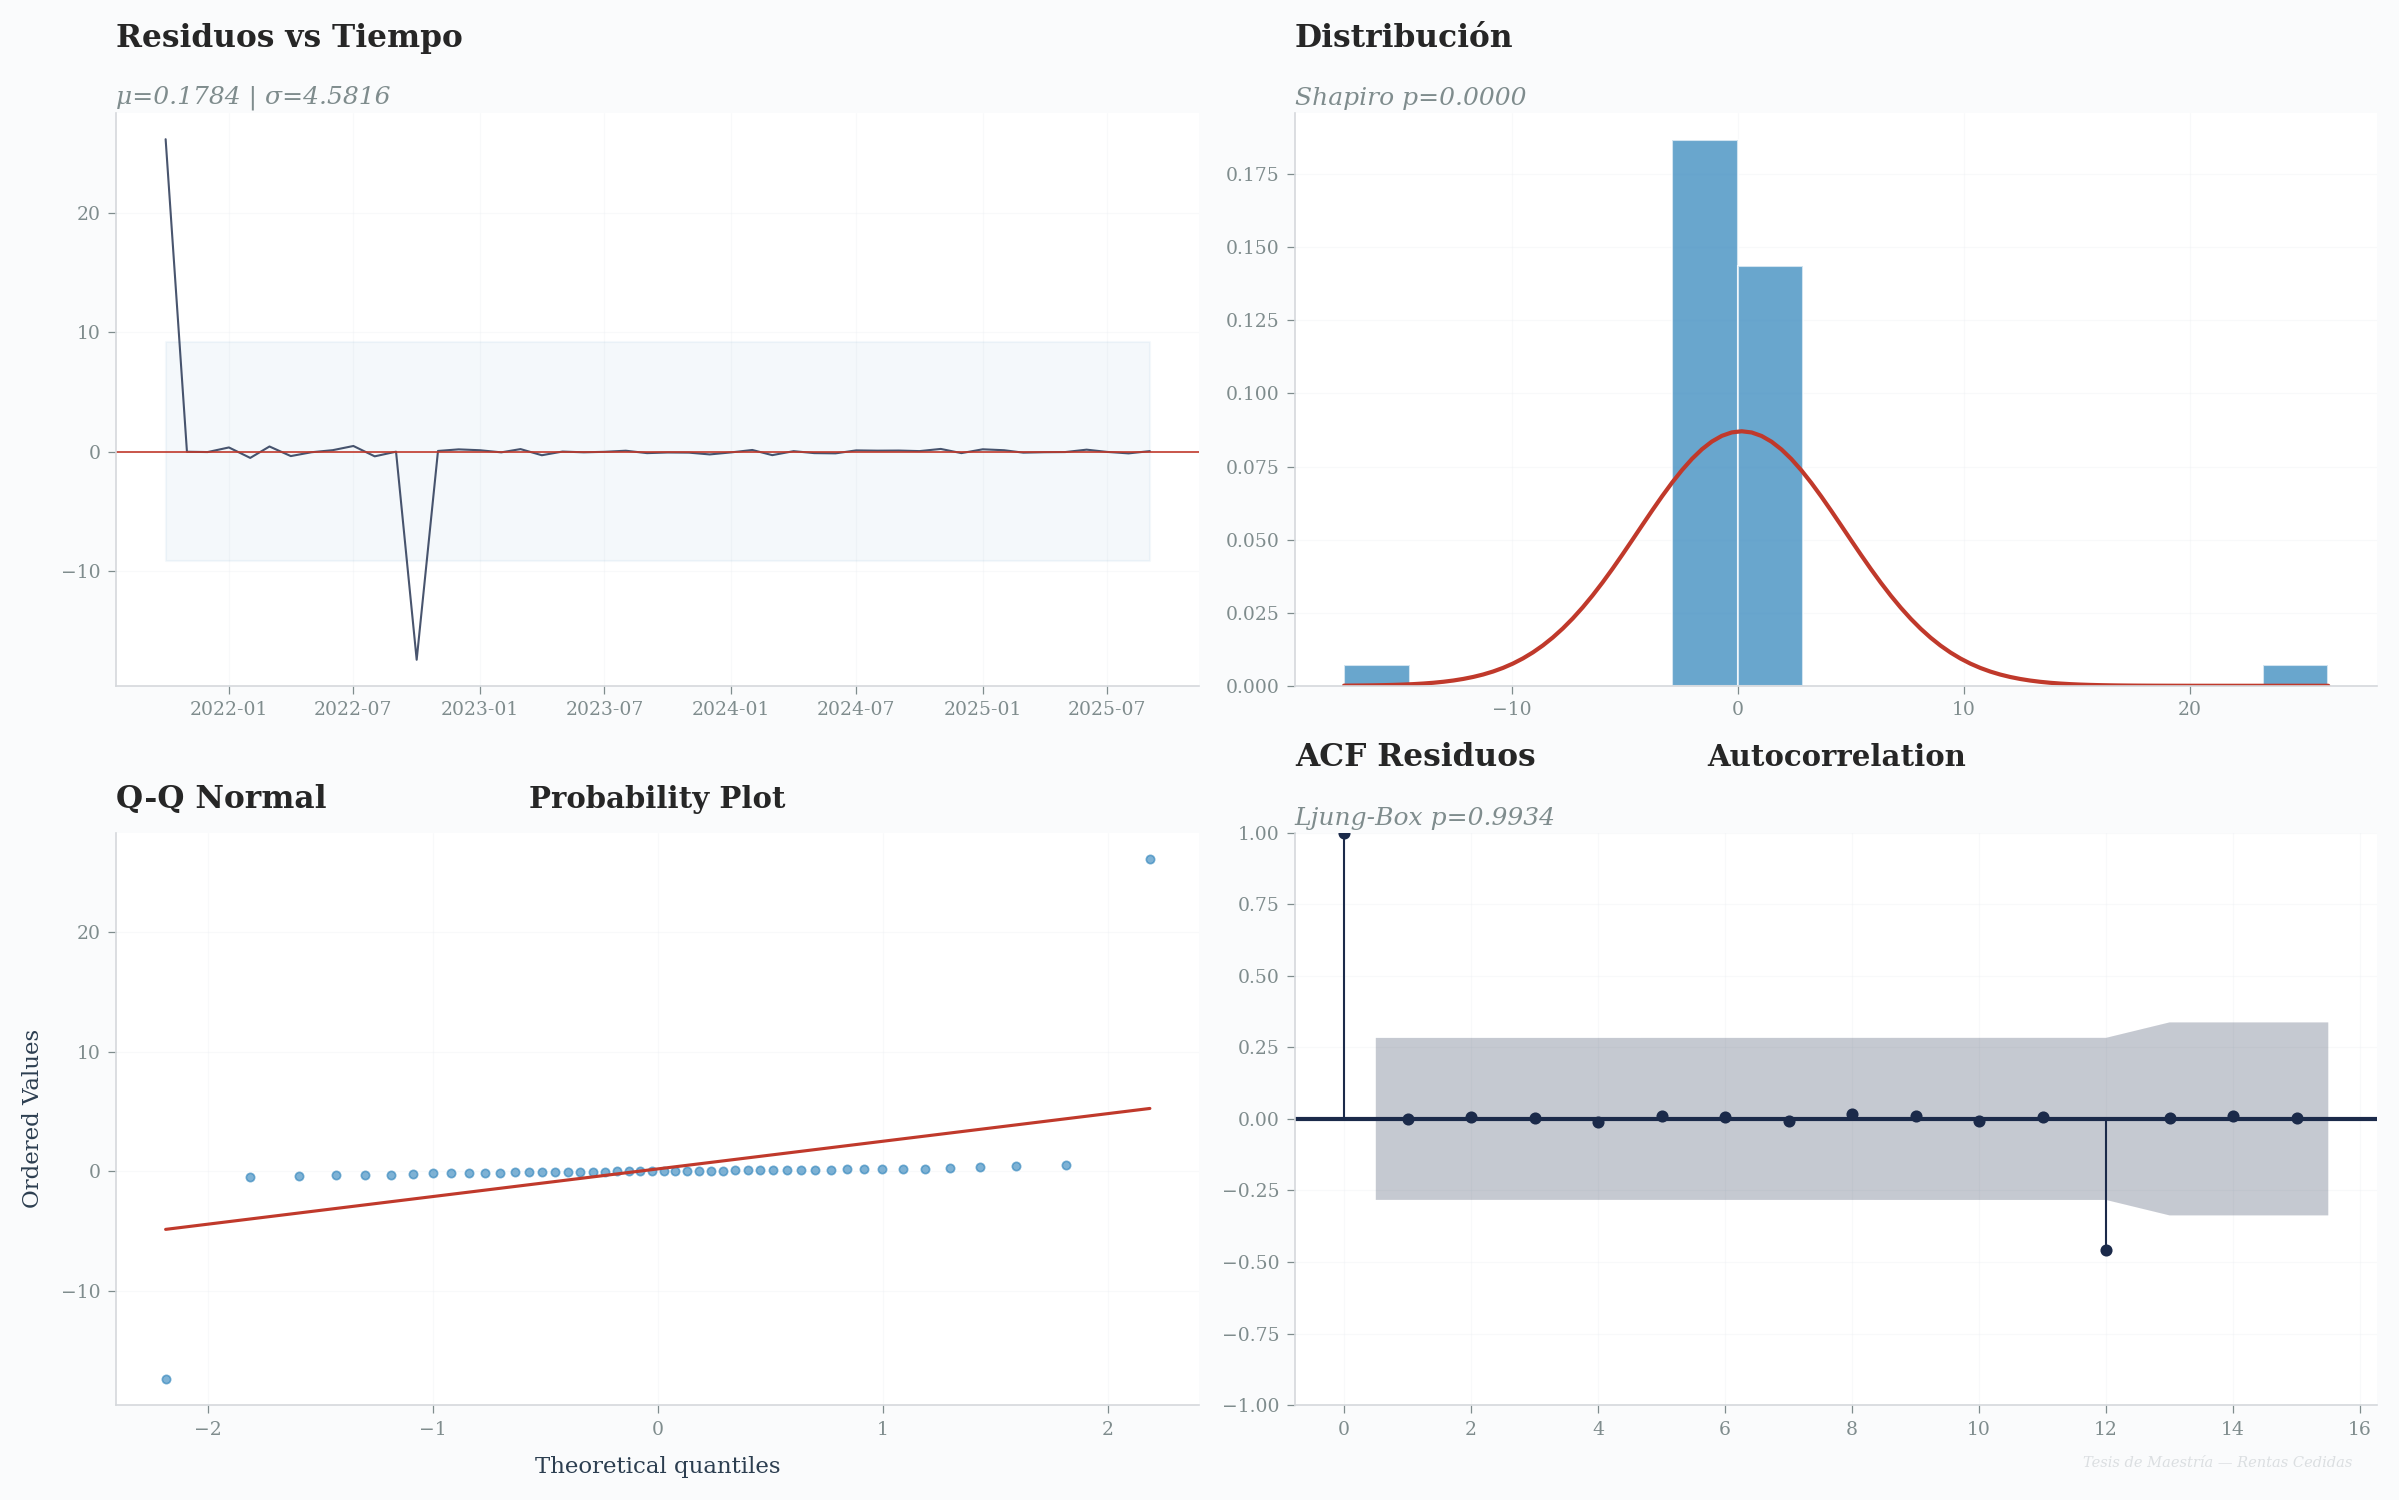

In [4]:
# ══════════════════════════════════════════════════════════════
# FASE V — Ajuste Óptimo + Diagnóstico de Residuos
# ══════════════════════════════════════════════════════════════

exog_opt = exog_train[BEST_EXOG_COLS] if BEST_EXOG_COLS else None
model_opt = SARIMAX(train_log, exog=exog_opt, order=BEST_ORDER,
                    seasonal_order=BEST_SEASONAL,
                    enforce_stationarity=False, enforce_invertibility=False)
results_opt = model_opt.fit(disp=False)

print(f"{'═'*70}\nMODELO ÓPTIMO — {BEST_CONFIG}  {best['label']}\n{'═'*70}")
print(results_opt.summary())

# ── Coeficientes ──
print(f"\n{'─'*70}\nCOEFICIENTES (α = 0.05)\n{'─'*70}")
for name, coef, pval in zip(results_opt.param_names,
                             results_opt.params, results_opt.pvalues):
    tipo = 'EXOG' if name in (BEST_EXOG_COLS or []) else 'SARIMA'
    print(f"  {name:<18} β={coef:>+10.6f}  p={pval:.4f}  "
          f"{'✅' if pval < .05 else '⚠️'}  [{tipo}]")

if BEST_EXOG_COLS:
    print(f"\n  Elasticidades (log-log):")
    for col in BEST_EXOG_COLS:
        if col in results_opt.param_names:
            i = list(results_opt.param_names).index(col)
            b = results_opt.params[i]
            print(f"    {col}: β={b:+.4f} → 1%↑{col} ≈ {b:+.4f}% Δrecaudo")

# ── Diagnóstico ──
residuos = results_opt.resid.dropna()
lb_lags = min(10, len(residuos)//3)
lb_p = acorr_ljungbox(residuos, lags=lb_lags, return_df=True)['lb_pvalue'].min()
sw_s, sw_p = stats.shapiro(residuos)
mid = len(residuos)//2
lev_s, lev_p = stats.levene(residuos.iloc[:mid], residuos.iloc[mid:])
t_s, t_p = stats.ttest_1samp(residuos, 0)

tests = [('Ljung-Box', lb_p), ('Shapiro-Wilk', sw_p),
         ('Levene', lev_p), ('t-test μ=0', t_p)]
print(f"\n{'═'*70}\nDIAGNÓSTICO DE RESIDUOS\n{'═'*70}")
n_pass = 0
for name, p in tests:
    ok = p > 0.05
    n_pass += ok
    print(f"  {name:<15}: p={p:.4f}  {'✅' if ok else '⚠️'}")
print(f"\n  Veredicto: {n_pass}/4 → "
      f"{'ACEPTABLE' if n_pass >= 3 else 'ACEPTABLE CON RESERVAS' if n_pass >= 2 else 'REVISAR'}")

# ── Gráfica 2×2 ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0,0]
ax.plot(residuos.index, residuos.values, color=C_PRIMARY, lw=1, alpha=.8)
ax.axhline(0, color=C_SECONDARY, lw=.8)
s2 = 2*residuos.std()
ax.fill_between(residuos.index, -s2, s2, alpha=.05, color=C_TERTIARY)
ax.grid(True, alpha=.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Residuos vs Tiempo',
                       f'μ={residuos.mean():.4f} | σ={residuos.std():.4f}')

ax = axes[0,1]
ax.hist(residuos, bins=15, color=C_TERTIARY, edgecolor='white', alpha=.7, density=True)
xn = np.linspace(residuos.min(), residuos.max(), 100)
ax.plot(xn, stats.norm.pdf(xn, residuos.mean(), residuos.std()),
        color=C_SECONDARY, lw=2)
ax.grid(True, alpha=.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Distribución', f'Shapiro p={sw_p:.4f}')

ax = axes[1,0]
qq = stats.probplot(residuos, dist='norm', plot=ax)
ax.get_lines()[0].set(color=C_TERTIARY, ms=4, alpha=.6)
ax.get_lines()[1].set(color=C_SECONDARY, lw=1.5)
ax.grid(True, alpha=.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Q-Q Normal', '')

ax = axes[1,1]
nl = min(15, len(residuos)//2-1)
if nl > 2:
    plot_acf(residuos, ax=ax, lags=nl, alpha=.05, color=C_PRIMARY,
             vlines_kwargs={'colors': C_PRIMARY, 'linewidth': 1})
ax.grid(True, alpha=.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'ACF Residuos', f'Ljung-Box p={lb_p:.4f}')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig); guardar_figura(fig, '05_sarimax_diagnostico', OUTPUTS_FIGURES)
plt.show()

---
## Fase VI — Pronóstico OOS + Producción 2026

1. **OOS (3 m):** Oct–Dic 2025 vs datos reales.
2. **Producción (12 m):** Re-entrenamiento completo → Ene–Dic 2026.

══════════════════════════════════════════════════════════════════════
PRONÓSTICO OOS — Sin_Exog
══════════════════════════════════════════════════════════════════════
  MAPE: 13.99% | RMSE: $42.5MM | MAE: $39.6MM

  2025-10  Real: $313.0MM  Pred: $261.5MM  Err: -16.5%
  2025-11  Real: $273.8MM  Pred: $323.1MM  Err: +18.0%
  2025-12  Real: $241.0MM  Pred: $222.9MM  Err: -7.5%


  📊 Figura guardada: 05_sarimax_oos.png


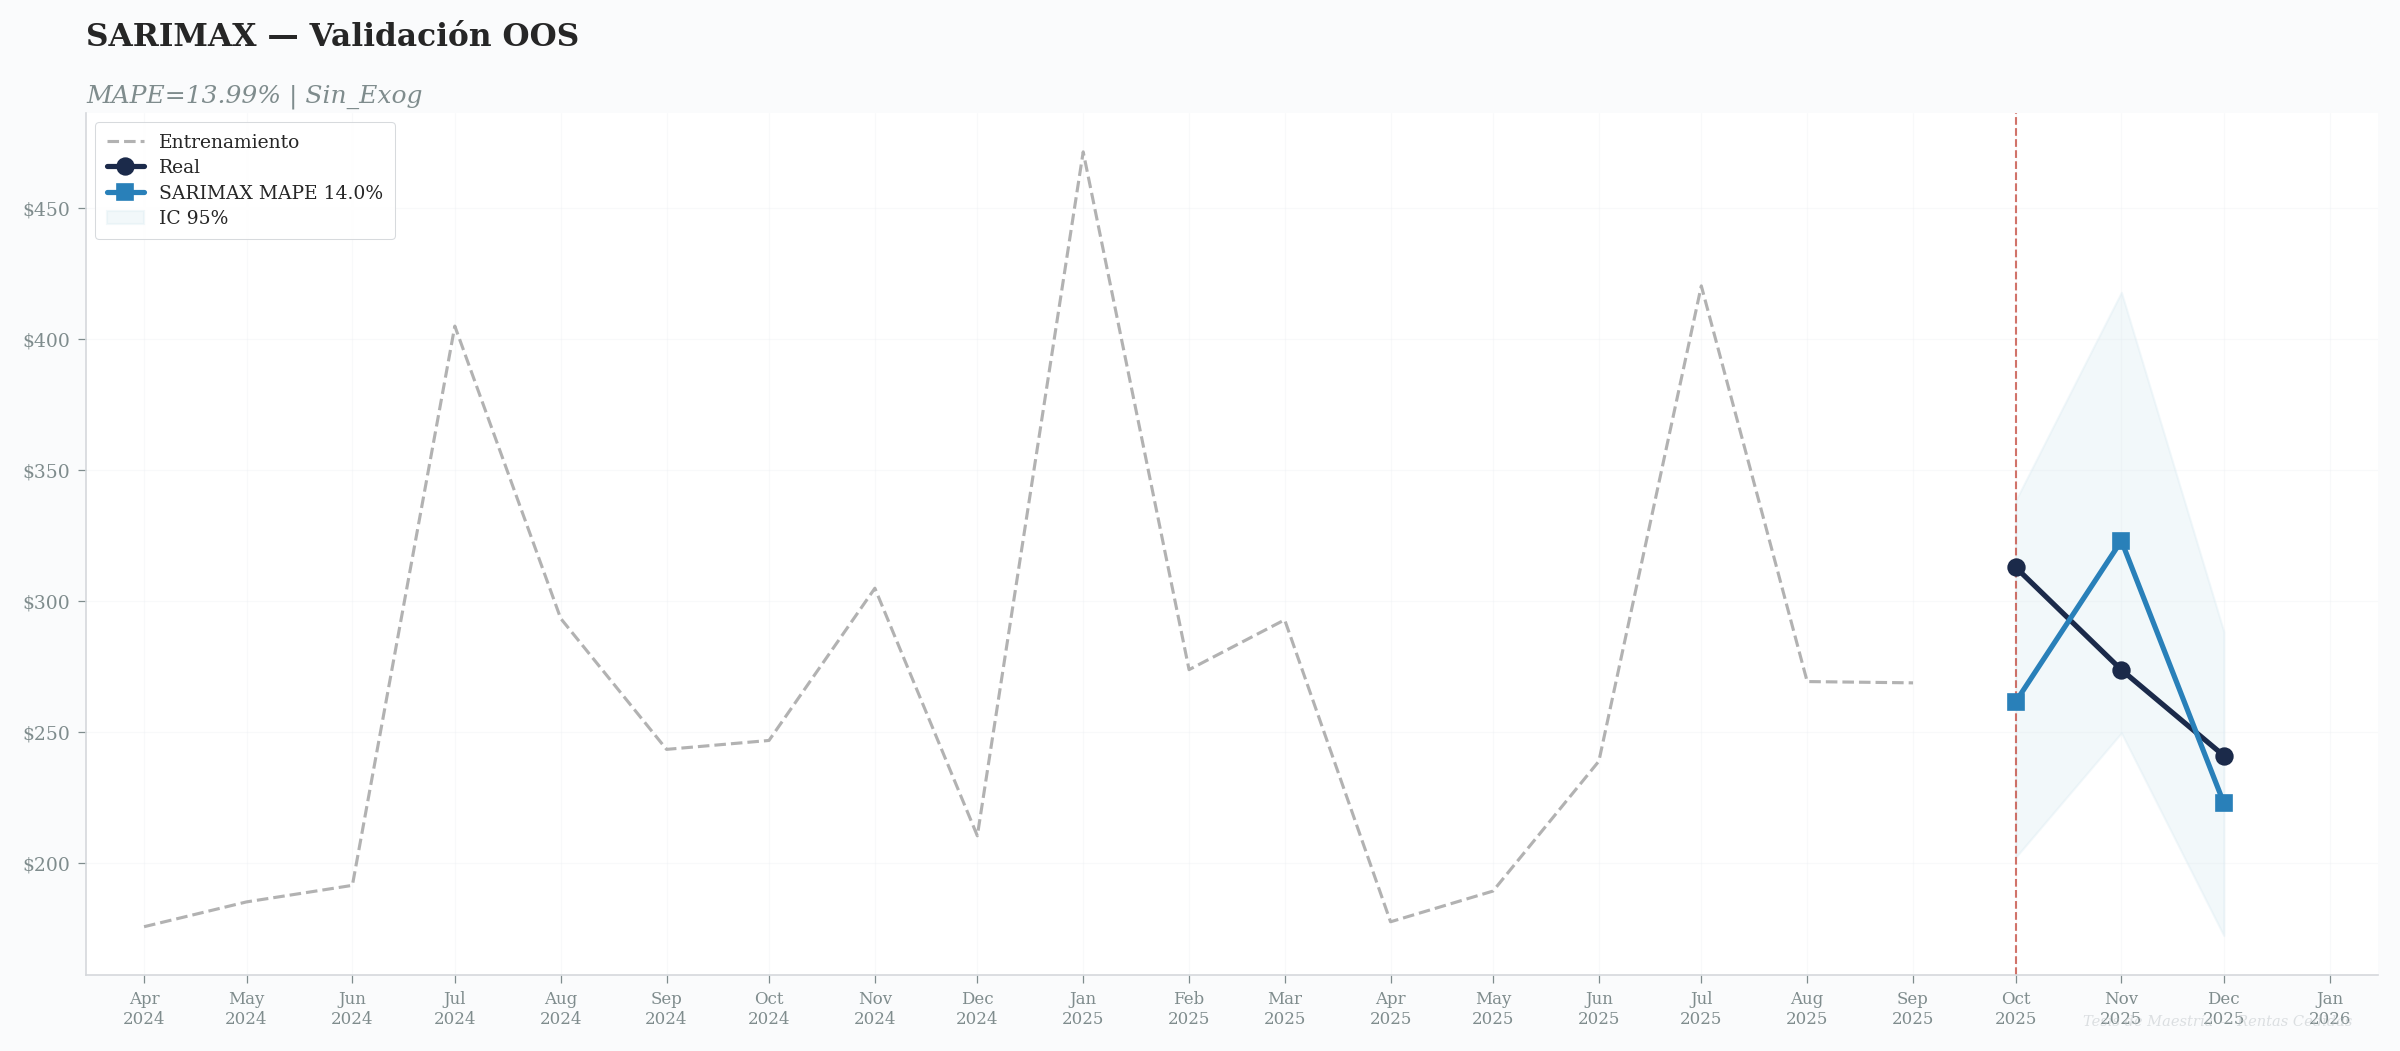


  ✅ sarimax_forecast.csv guardado

══════════════════════════════════════════════════════════════════════
PRONÓSTICO 2026 — Sin_Exog
══════════════════════════════════════════════════════════════════════
  2026-01  $     500.8MM  [$386.0 – $649.8]
  2026-02  $     290.8MM  [$224.1 – $377.4]
  2026-03  $     311.0MM  [$239.7 – $403.6]
  2026-04  $     188.6MM  [$145.3 – $244.7]
  2026-05  $     201.0MM  [$154.9 – $260.9]
  2026-06  $     253.7MM  [$195.5 – $329.2]
  2026-07  $     446.5MM  [$344.1 – $579.3]
  2026-08  $     286.0MM  [$220.4 – $371.1]
  2026-09  $     285.5MM  [$220.0 – $370.4]
  2026-10  $     332.4MM  [$256.2 – $431.3]
  2026-11  $     290.8MM  [$224.1 – $377.3]
  2026-12  $     256.0MM  [$197.3 – $332.1]
  ──────────────────────────────────────────────────
  TOTAL 2026: $3,643.1MM  (vs 2025: +6.2%)


  📊 Figura guardada: 05_sarimax_produccion_2026.png


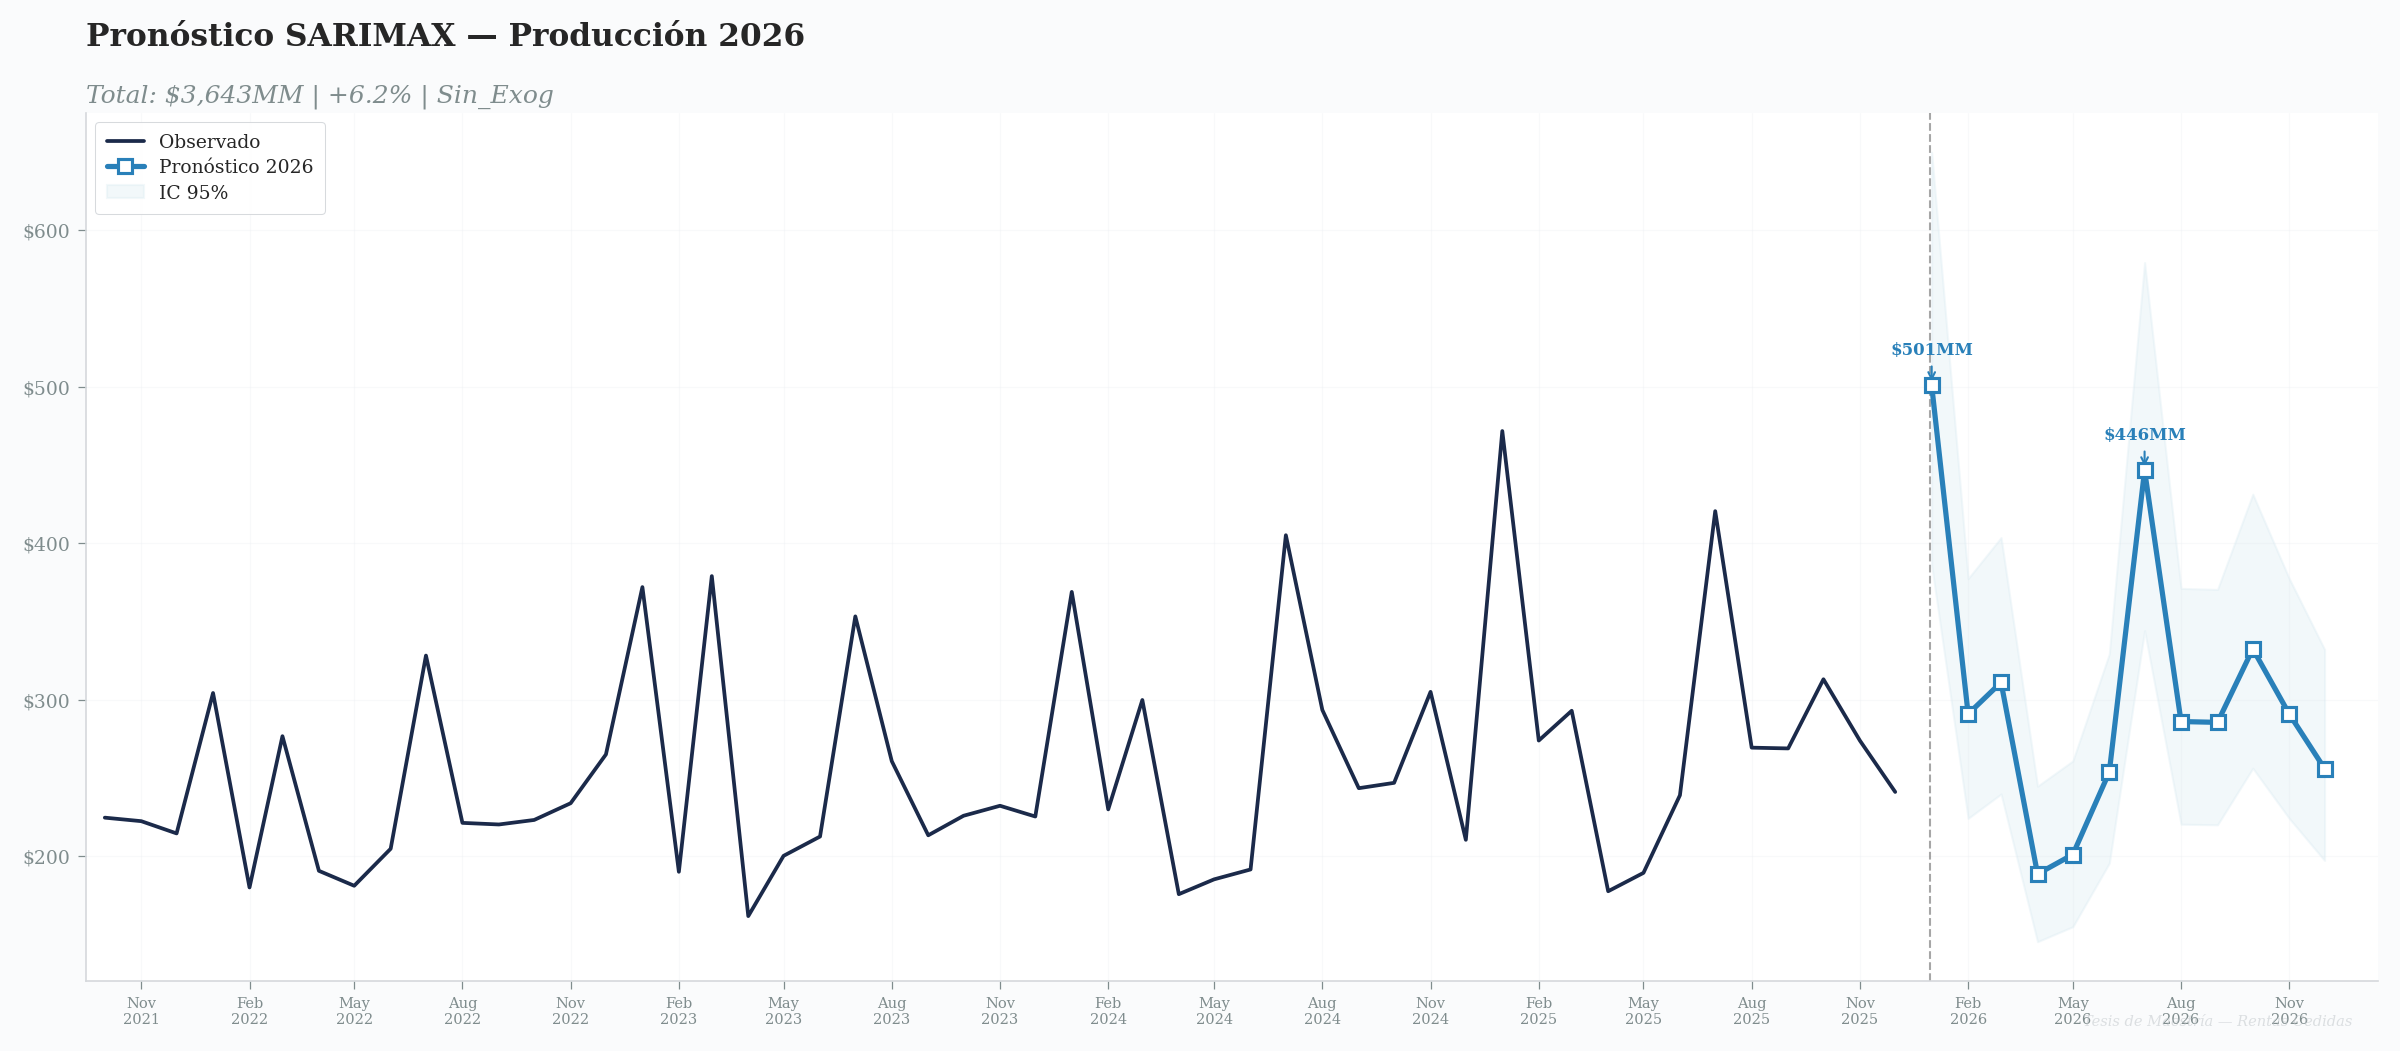

  ✅ sarimax_forecast_2026.csv guardado


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE VI — Pronóstico OOS (3m) + Producción 2026 (12m)
# ══════════════════════════════════════════════════════════════

# ── A. Out-of-Sample ──
exog_oos = exog_test[BEST_EXOG_COLS] if BEST_EXOG_COLS else None
fc = results_opt.get_forecast(steps=len(test), exog=exog_oos)
pred_log, ci_log = fc.predicted_mean, fc.conf_int(alpha=.05)

pred = np.expm1(pred_log)
ci_lo, ci_hi = np.expm1(ci_log.iloc[:,0]), np.expm1(ci_log.iloc[:,1])

mape_oos = mean_absolute_percentage_error(test, pred) * 100
rmse_oos = np.sqrt(mean_squared_error(test, pred))
mae_oos  = mean_absolute_error(test, pred)

print(f"{'═'*70}\nPRONÓSTICO OOS — {BEST_CONFIG}\n{'═'*70}")
print(f"  MAPE: {mape_oos:.2f}% | RMSE: ${rmse_oos/1e9:,.1f}MM | MAE: ${mae_oos/1e9:,.1f}MM\n")
for f in test.index:
    r, p2 = test.loc[f], pred.loc[f]
    print(f"  {f.strftime('%Y-%m')}  Real: ${r/1e9:,.1f}MM  Pred: ${p2/1e9:,.1f}MM  "
          f"Err: {(p2-r)/r*100:+.1f}%")

# ── Viz OOS ──
fig, ax = plt.subplots(figsize=(16, 7))
nh = min(18, len(train))
ax.plot(train.index[-nh:], train.values[-nh:]/1e9, color='grey', lw=1.5,
        ls='--', alpha=.6, label='Entrenamiento')
ax.plot(test.index, test.values/1e9, color=C_PRIMARY, lw=2.5, marker='o',
        ms=8, label='Real', zorder=5)
ax.plot(pred.index, pred.values/1e9, color=C_TERTIARY, lw=2.5, marker='s',
        ms=8, label=f'SARIMAX MAPE {mape_oos:.1f}%', zorder=5)
ax.fill_between(ci_lo.index, ci_lo.values/1e9, ci_hi.values/1e9,
                color=C_CI_FILL, alpha=.3, label='IC 95%')
ax.axvline(pd.Timestamp(VAL_START), color=C_SECONDARY, ls='--', lw=1, alpha=.7)
ax.set_xlim(pd.Timestamp('2024-03-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=8); ax.grid(True, alpha=.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'SARIMAX — Validación OOS',
                       f'MAPE={mape_oos:.2f}% | {BEST_CONFIG}')
    formato_pesos_eje(ax, eje='y'); leyenda_profesional(ax, loc='upper left')
plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig); guardar_figura(fig, '05_sarimax_oos', OUTPUTS_FIGURES)
plt.show()

pd.DataFrame({
    'Fecha': test.index.strftime('%Y-%m-%d'),
    'Real': test.values, 'Pronostico_SARIMAX': pred.values,
    'IC_Inferior': ci_lo.values, 'IC_Superior': ci_hi.values,
    'Error_Pct': (pred.values - test.values) / test.values * 100,
}).to_csv(OUTPUTS_FORECASTS / 'sarimax_forecast.csv', index=False)
print(f"\n  ✅ sarimax_forecast.csv guardado")

# ── B. Producción 2026 ──
serie_log_full = np.log1p(serie_full)
exog_full_opt = exog_full[BEST_EXOG_COLS] if BEST_EXOG_COLS else None
model_full = SARIMAX(serie_log_full, exog=exog_full_opt,
                     order=BEST_ORDER, seasonal_order=BEST_SEASONAL,
                     enforce_stationarity=False, enforce_invertibility=False)
results_full = model_full.fit(disp=False)

dates_26 = pd.date_range('2026-01-01', periods=HORIZONTE_PRONOSTICO, freq='MS')
if BEST_EXOG_COLS:
    exog_26 = pd.DataFrame(index=dates_26)
    if 'IPC' in BEST_EXOG_COLS:
        last_ipc = ipc_full.iloc[-1]
        tm = (1 + MACRO_DATA[2026]['IPC']/100)**(1/12) - 1
        exog_26['IPC'] = np.log([last_ipc*(1+tm)**m
                                  for m in range(1, HORIZONTE_PRONOSTICO+1)])
    if 'UPC' in BEST_EXOG_COLS:
        exog_26['UPC'] = np.log(
            raw_series['UPC'].iloc[-1] * (1 + MACRO_DATA[2026].get('UPC',0)/100))
    if 'SMLV' in BEST_EXOG_COLS:
        exog_26['SMLV'] = np.log(SMLV_COP[2026])
    if 'Consumo' in BEST_EXOG_COLS:
        exog_26['Consumo'] = np.log(
            raw_series['Consumo'].iloc[-1] * (1 + MACRO_DATA[2026].get('Consumo_Hogares',0)/100))
    if 'Desempleo' in BEST_EXOG_COLS:
        exog_26['Desempleo'] = np.log(MACRO_DATA[2026]['Desempleo'])
    exog_fc = exog_26[BEST_EXOG_COLS]
else:
    exog_fc = None

fc26 = results_full.get_forecast(steps=HORIZONTE_PRONOSTICO, exog=exog_fc)
p26 = np.expm1(fc26.predicted_mean)
ci26 = fc26.conf_int(alpha=.05)
ci26_lo, ci26_hi = np.expm1(ci26.iloc[:,0]), np.expm1(ci26.iloc[:,1])

total_26 = p26.sum()
total_25 = serie_full.loc['2025-01-01':'2025-12-31'].sum()
crec = (total_26 - total_25) / total_25 * 100

print(f"\n{'═'*70}\nPRONÓSTICO 2026 — {BEST_CONFIG}\n{'═'*70}")
for f, v, lo, hi in zip(p26.index, p26.values, ci26_lo.values, ci26_hi.values):
    print(f"  {f.strftime('%Y-%m')}  ${v/1e9:>10,.1f}MM  "
          f"[${lo/1e9:,.1f} – ${hi/1e9:,.1f}]")
print(f"  {'─'*50}")
print(f"  TOTAL 2026: ${total_26/1e9:,.1f}MM  (vs 2025: {crec:+.1f}%)")

# ── Viz producción ──
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(serie_full.index, serie_full.values/1e9, color=C_PRIMARY, lw=1.8,
        label='Observado')
ax.plot(p26.index, p26.values/1e9, color=C_TERTIARY, lw=2.5, marker='s',
        ms=7, markerfacecolor='white', markeredgecolor=C_TERTIARY,
        markeredgewidth=1.5, label='Pronóstico 2026', zorder=5)
ax.fill_between(ci26_lo.index, ci26_lo.values/1e9, ci26_hi.values/1e9,
                color=C_CI_FILL, alpha=.3, label='IC 95%')
ax.axvline(pd.Timestamp('2025-12-31'), color='grey', ls='--', lw=1, alpha=.7)
for m in MESES_PICO:
    fp = pd.Timestamp(f'2026-{m:02d}-01')
    if fp in p26.index:
        ax.annotate(f'${p26.loc[fp]/1e9:.0f}MM', xy=(fp, p26.loc[fp]/1e9),
                    xytext=(0,15), textcoords='offset points', fontsize=8,
                    fontweight='bold', color=C_TERTIARY, ha='center',
                    arrowprops=dict(arrowstyle='->', color=C_TERTIARY, lw=1))
ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2027-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7); ax.grid(True, alpha=.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Pronóstico SARIMAX — Producción 2026',
                       f'Total: ${total_26/1e9:,.0f}MM | {crec:+.1f}% | {BEST_CONFIG}')
    formato_pesos_eje(ax, eje='y'); leyenda_profesional(ax, loc='upper left')
plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig); guardar_figura(fig, '05_sarimax_produccion_2026', OUTPUTS_FIGURES)
plt.show()

pd.DataFrame({'Pronostico': p26.values, 'Limite_Inferior': ci26_lo.values,
              'Limite_Superior': ci26_hi.values}, index=p26.index
             ).rename_axis('Fecha').to_csv(
                 OUTPUTS_FORECASTS / 'sarimax_forecast_2026.csv')
print(f"  ✅ sarimax_forecast_2026.csv guardado")

══════════════════════════════════════════════════════════════════════
COMPARACIÓN SARIMAX vs SARIMA
══════════════════════════════════════════════════════════════════════
  Métrica                       SARIMA         SARIMAX          Δ
  ────────────────────────────────────────────────────────────
  MAPE (%)                      13.99%          13.99%     -0.00
  RMSE (MM$)                     42.5            42.5       -0.0
  AICc                         -34.18          -34.18      +0.00
  Total 2026           $      3,643.1  $      3,643.1       +0.0

──────────────────────────────────────────────────────────────────────
RANKING DE CONFIGURACIONES
──────────────────────────────────────────────────────────────────────
   1. Sin_Exog                       AICc=-34.18 (Δ=+0.0) ★
   2. UPC                            AICc=-32.15 (Δ=+2.0)
   3. SMLV                           AICc=-32.05 (Δ=+2.1)
   4. Consumo                        AICc=-32.05 (Δ=+2.1)
   5. Desempleo                    

  📊 Figura guardada: 05_sarimax_vs_sarima.png


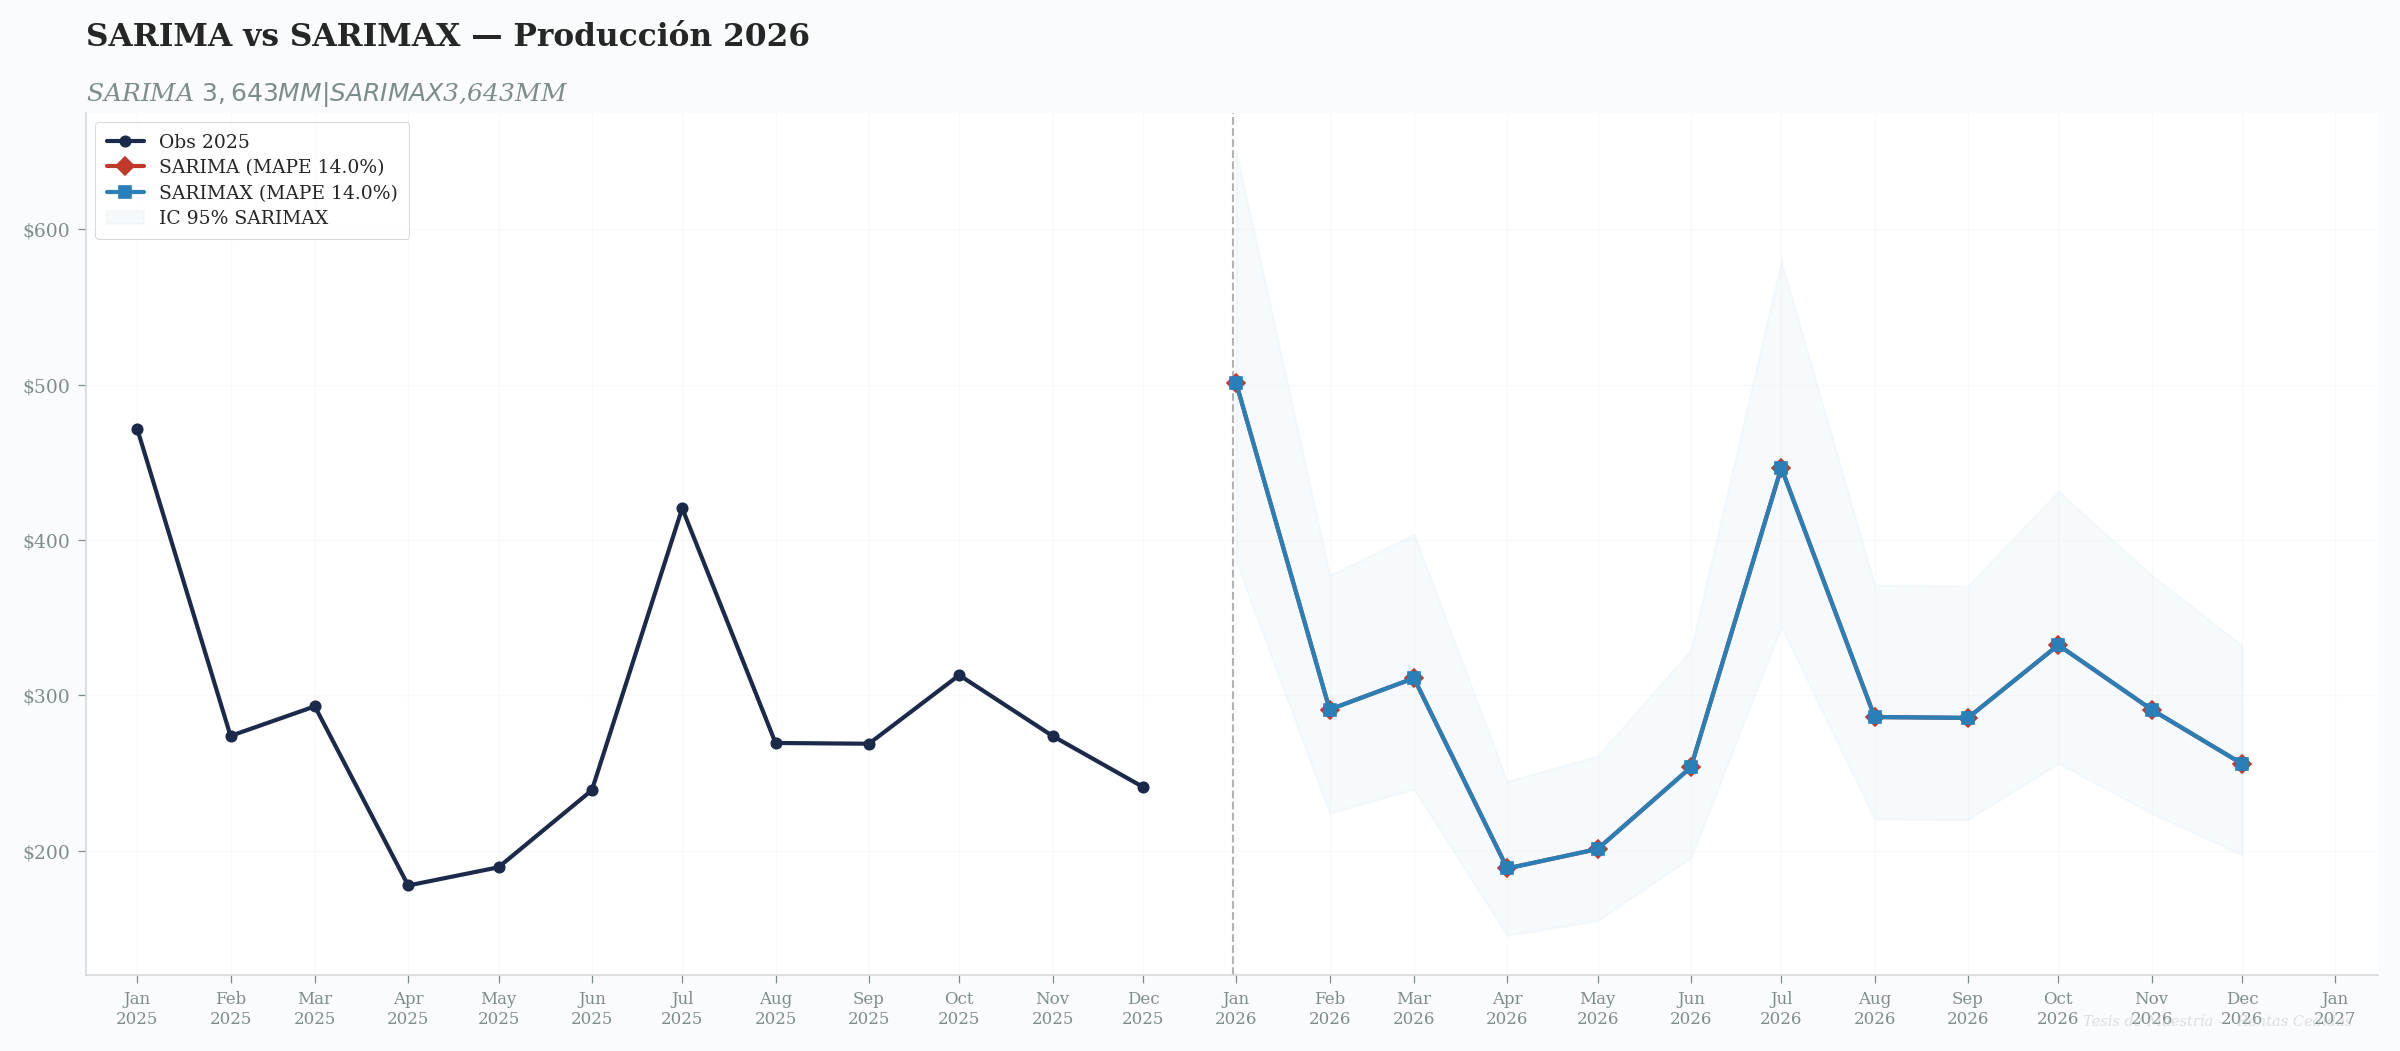


  ✅ sarimax_metricas.csv guardado


In [6]:
# ══════════════════════════════════════════════════════════════
# FASE VII — Comparación SARIMAX vs SARIMA + Recomendación
# ══════════════════════════════════════════════════════════════

k_opt = results_opt.df_model + 1
aicc_sx = calc_aicc(results_opt.aic, k_opt, results_opt.nobs)
sx_modelo = f"SARIMAX{best['label']}"
if BEST_EXOG_COLS: sx_modelo += f"+{'+'.join(BEST_EXOG_COLS)}"

# ── Cargar SARIMA (NB 04) ──
sarima_ok = (OUTPUTS_REPORTS / 'sarima_metricas.csv').exists()
if sarima_ok:
    sm = pd.read_csv(OUTPUTS_REPORTS / 'sarima_metricas.csv')
    s_mape, s_rmse = sm['MAPE'].iloc[0], sm['RMSE_MM'].iloc[0]
    s_aicc, s_tot  = sm['AICc'].iloc[0], sm['Total_2026_MM'].iloc[0]
    s_crec, s_mod  = sm['Crec_vs_2025'].iloc[0], sm['Modelo'].iloc[0]

    dm, dr = mape_oos - s_mape, rmse_oos/1e9 - s_rmse
    da, dt = aicc_sx - s_aicc, total_26/1e9 - s_tot

    print(f"{'═'*70}\nCOMPARACIÓN SARIMAX vs SARIMA\n{'═'*70}")
    print(f"  {'Métrica':<20} {'SARIMA':>15} {'SARIMAX':>15} {'Δ':>10}")
    print(f"  {'─'*60}")
    print(f"  {'MAPE (%)':<20} {s_mape:>14.2f}% {mape_oos:>14.2f}% {dm:>+9.2f}")
    print(f"  {'RMSE (MM$)':<20} {s_rmse:>14.1f}  {rmse_oos/1e9:>14.1f}  {dr:>+9.1f}")
    print(f"  {'AICc':<20} {s_aicc:>14.2f}  {aicc_sx:>14.2f}  {da:>+9.2f}")
    print(f"  {'Total 2026':<20} ${s_tot:>13,.1f}  ${total_26/1e9:>13,.1f}  {dt:>+9.1f}")
    better = dm < -.5 and da < -2
else:
    better = False

# ── Ranking configs ──
cfg_best = {}
for r in todos:
    c = r['config']
    if c not in cfg_best or r['AICc'] < cfg_best[c]['AICc']:
        cfg_best[c] = r
ranking = sorted(cfg_best.values(), key=lambda x: x['AICc'])
best_aicc0 = ranking[0]['AICc']

print(f"\n{'─'*70}\nRANKING DE CONFIGURACIONES\n{'─'*70}")
for i, rc in enumerate(ranking, 1):
    d = rc['AICc'] - best_aicc0
    print(f"  {i:>2}. {rc['config']:<30} AICc={rc['AICc']:.2f} (Δ={d:+.1f})"
          f"{' ★' if i==1 else ''}")

# ── Importancia de variables ──
if BEST_EXOG_COLS:
    print(f"\n{'─'*70}\nIMPORTANCIA DE VARIABLES\n{'─'*70}")
    for col in BEST_EXOG_COLS:
        if col in results_opt.param_names:
            i = list(results_opt.param_names).index(col)
            b, se, pv = results_opt.params[i], results_opt.bse[i], results_opt.pvalues[i]
            print(f"  {col}: β={b:+.6f}±{se:.6f} t={b/se:.2f} p={pv:.4f} "
                  f"{'✅' if pv<.05 else '❌'}")

# ── Recomendación ──
print(f"\n{'═'*70}")
print(f"  R E C O M E N D A C I Ó N   F I N A L")
print(f"{'═'*70}")
print(f"\n  Modelos evaluados: {len(baseline_results) + len(todos)}")
print(f"  Combos exógenas: 15 (todas las de 4 variables)")
print(f"\n  ★ ELECCIÓN: {BEST_CONFIG}  {best['label']}  AICc={best['AICc']:.2f}")
print(f"    MAPE OOS: {mape_oos:.2f}% | Total 2026: ${total_26/1e9:,.1f}MM ({crec:+.1f}%)")

if BEST_EXOG_COLS:
    print(f"\n  → [{', '.join(BEST_EXOG_COLS)}] MEJORAN el pronóstico.")
    print(f"  ⚠️ Riesgo: exógenas requieren proyecciones macro futuras.")
else:
    print(f"\n  → SARIMA puro supera todas las configuraciones con exógenas.")
    print(f"    La estacionalidad SAR ya captura los ciclos macro anuales.")
    print(f"    Parsimonia: menos parámetros = menor riesgo operacional.")

# ── SARIMA vs SARIMAX gráfica ──
if sarima_ok and (OUTPUTS_FORECASTS / 'sarima_produccion_12m.csv').exists():
    sp = pd.read_csv(OUTPUTS_FORECASTS / 'sarima_produccion_12m.csv',
                     parse_dates=['Fecha'], index_col='Fecha')
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.plot(serie_full.index[-12:], serie_full.values[-12:]/1e9,
            color=C_PRIMARY, lw=2, marker='o', ms=5, label='Obs 2025', zorder=5)
    ax.plot(sp.index, sp['Pronostico'].values/1e9, color=C_SECONDARY, lw=2,
            marker='D', ms=6, label=f'SARIMA (MAPE {s_mape:.1f}%)', zorder=4)
    ax.plot(p26.index, p26.values/1e9, color=C_TERTIARY, lw=2, marker='s',
            ms=6, label=f'SARIMAX (MAPE {mape_oos:.1f}%)', zorder=4)
    ax.fill_between(ci26_lo.index, ci26_lo.values/1e9, ci26_hi.values/1e9,
                    color=C_CI_FILL, alpha=.2, label='IC 95% SARIMAX')
    ax.axvline(pd.Timestamp('2025-12-31'), color='grey', ls='--', lw=1, alpha=.6)
    ax.set_xlim(pd.Timestamp('2024-12-15'), pd.Timestamp('2027-01-15'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.tick_params(axis='x', labelsize=8); ax.grid(True, alpha=.3)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'SARIMA vs SARIMAX — Producción 2026',
                           f'SARIMA ${s_tot:,.0f}MM | SARIMAX ${total_26/1e9:,.0f}MM')
        formato_pesos_eje(ax, eje='y'); leyenda_profesional(ax, loc='upper left')
    plt.tight_layout()
    if _VIZ_THEME_LOADED:
        marca_agua(fig); guardar_figura(fig, '05_sarimax_vs_sarima', OUTPUTS_FIGURES)
    plt.show()

# ── Exportar métricas ──
pd.DataFrame([{
    'Modelo': sx_modelo, 'Transformacion': 'log1p',
    'Train': f"{len(train)}m", 'Test': f"{len(test)}m",
    'MAPE': round(mape_oos, 2), 'RMSE_MM': round(rmse_oos/1e9, 1),
    'MAE_MM': round(mae_oos/1e9, 1),
    'AICc': round(aicc_sx, 2), 'AIC': round(results_opt.aic, 2),
    'BIC': round(results_opt.bic, 2),
    'Ljung_Box_p': round(lb_p, 4), 'Shapiro_Wilk_p': round(sw_p, 4),
    'Total_2026_MM': round(total_26/1e9, 1), 'Crec_vs_2025': round(crec, 1),
    'Exogenas': '+'.join(BEST_EXOG_COLS) if BEST_EXOG_COLS else 'Ninguna',
    'Modelos_evaluados': len(baseline_results) + len(todos),
}]).to_csv(OUTPUTS_REPORTS / 'sarimax_metricas.csv', index=False)
print(f"\n  ✅ sarimax_metricas.csv guardado")

---
## Conclusiones

1. **5 exógenas** (IPC, UPC, SMLV, Consumo, **Desempleo**) evaluadas en **31 combinaciones**
   con grid search de 2 etapas (~132 modelos).
2. **Desempleo** (DANE GEIH) captura el efecto del mercado laboral sobre la capacidad
   contributiva de los hogares — se espera coeficiente negativo (mayor desempleo → menor recaudo).
3. **Multicolinealidad** (VIF elevado) limita el valor marginal de incluir múltiples
   variables macro — la estacionalidad SAR ya captura los ciclos anuales.
4. **Consumo de Hogares** mide demanda agregada real, pero comparte tendencia
   con IPC/UPC, limitando su aporte independiente.
5. Si SARIMAX no mejora > 2 pts AICc y > 0.5 pp MAPE sobre SARIMA:
   **mantener SARIMA** (parsimonia + menor riesgo operacional).

---
*NB 05 · SARIMAX · 5 Exógenas (incl. Desempleo) · 31 Combinaciones · Grid 2 Etapas*